In [1]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/MyDrive/GraphIDS

Mounted at /gdrive
/gdrive/MyDrive/GraphIDS


In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import numpy as np
plt.style.use('default')
%matplotlib inline

#GPU setup
# import os
# os.environ["NX_CUGRAPH_AUTOCONFIG"] = "True"

# import cugraph
# import cudf

# Dataset

In [77]:
dataset = pd.read_csv("data/NF-UNSW-NB15-v3/NF-UNSW-NB15-v3.csv")

In [78]:
dataset.sample(5)

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
292699,1424239874024,1424239874060,59.166.0.1,54011,149.171.126.3,30288,6,36.0,3926,66,...,0,4,0,0,0,4,0,0,0,Benign
1176264,1424228271654,1424228271659,59.166.0.9,3059,149.171.126.6,46896,6,0.0,528,10,...,0,3,0,0,0,1,0,0,0,Benign
1060633,1424242872855,1424242872860,59.166.0.4,49475,149.171.126.4,48011,6,11.0,4632,18,...,0,1,0,0,0,1,0,0,0,Benign
237823,1424224891486,1424224891487,175.45.176.0,6245,149.171.126.12,111,17,11.0,168,2,...,0,0,0,0,0,0,0,0,1,Reconnaissance
1603869,1421941812907,1421941814430,59.166.0.1,26794,149.171.126.6,21,6,37.0,597,11,...,0,1006,205,353,0,1006,195,335,0,Benign


In [79]:
print(dataset['Label'].value_counts())
print(dataset['Attack'].value_counts())

perc_benign = dataset['Label'].value_counts()[0] / dataset['Label'].value_counts().sum()
print(f"\nbenign: {perc_benign:2f}\nmalicious: {1-perc_benign:2f}\n")

Label
0    2237731
1     127693
Name: count, dtype: int64
Attack
Benign            2237731
Exploits            42748
Fuzzers             33816
Generic             19651
Reconnaissance      17074
DoS                  5980
Backdoor             4659
Shellcode            2381
Analysis             1226
Worms                 158
Name: count, dtype: int64

benign: 0.946017
malicious: 0.053983



In [80]:
(225316 + 224942 + 224766 + 224274 + 223608 + 222835 + 215681 + 215238 + 214339 + 214165) / degree_df['in_degree'].sum()

np.float64(0.9322489329608561)

In [81]:
#Obtain list unique ip addresses (nodes).
# ip_addresses = cudf.concat(dataset['IPV4_SRC_ADDR'], dataset['IPV4_DST_ADDR']).unique()
ip_addresses = pd.concat([dataset['IPV4_SRC_ADDR'], dataset['IPV4_DST_ADDR']]).unique()

#There are a total of 44 nodes in the entire network
print(np.sort(ip_addresses))

#Aggregate the out and in-degree of each node and its total.
out_degree = dataset['IPV4_SRC_ADDR'].value_counts().rename('out_degree')
in_degree = dataset['IPV4_DST_ADDR'].value_counts().rename('in_degree')
degree_df = pd.concat([out_degree, in_degree], axis=1).fillna(0)

degree_df['total_degree'] = degree_df['out_degree'] + degree_df['in_degree']
degree_df = degree_df.astype(int)
degree_df.index.name = 'IP_Address'

degree_df['in_degree'].sum()

# print(degree_df.sort_values(by='out_degree', ascending=False))
print(degree_df.sort_values(by='in_degree', ascending=False))
# print(degree_df.sort_values(by='total_degree', ascending=False)[:10])

['10.40.182.1' '10.40.182.255' '10.40.182.6' '10.40.198.10' '10.40.85.1'
 '10.40.85.10' '127.0.0.1' '149.171.126.0' '149.171.126.1'
 '149.171.126.10' '149.171.126.11' '149.171.126.12' '149.171.126.13'
 '149.171.126.14' '149.171.126.15' '149.171.126.16' '149.171.126.17'
 '149.171.126.18' '149.171.126.19' '149.171.126.2' '149.171.126.3'
 '149.171.126.4' '149.171.126.5' '149.171.126.6' '149.171.126.7'
 '149.171.126.8' '149.171.126.9' '175.45.176.0' '175.45.176.1'
 '175.45.176.2' '175.45.176.3' '192.168.241.243' '192.168.241.50'
 '224.0.0.5' '59.166.0.0' '59.166.0.1' '59.166.0.2' '59.166.0.3'
 '59.166.0.4' '59.166.0.5' '59.166.0.6' '59.166.0.7' '59.166.0.8'
 '59.166.0.9']
                 out_degree  in_degree  total_degree
IP_Address                                          
149.171.126.4           420     224702        225122
149.171.126.2           413     224626        225039
149.171.126.3           401     224563        224964
149.171.126.0           350     224024        224374
149.1

In [82]:
degree_df['in_degree_asymmetry'] = degree_df['in_degree'] / degree_df['total_degree']
degree_df['out_degree_asymmetry'] = degree_df['out_degree'] / degree_df['total_degree']

In [83]:
print(degree_df['out_degree_asymmetry'].sort_values(ascending=False)[:15])
print(degree_df['in_degree_asymmetry'].sort_values(ascending=False)[:15])

IP_Address
10.40.182.6     1.000000
10.40.85.10     1.000000
10.40.182.1     1.000000
10.40.85.1      1.000000
59.166.0.7      0.998546
59.166.0.6      0.998350
59.166.0.4      0.998314
59.166.0.3      0.998277
59.166.0.9      0.998264
59.166.0.8      0.998219
59.166.0.2      0.998215
59.166.0.0      0.998184
59.166.0.5      0.998070
59.166.0.1      0.997940
175.45.176.2    0.996855
Name: out_degree_asymmetry, dtype: float64
IP_Address
224.0.0.5         1.000000
10.40.198.10      1.000000
192.168.241.50    1.000000
10.40.182.255     1.000000
149.171.126.0     0.998440
149.171.126.7     0.998435
149.171.126.9     0.998365
149.171.126.6     0.998357
149.171.126.1     0.998259
149.171.126.3     0.998217
149.171.126.2     0.998165
149.171.126.4     0.998134
149.171.126.5     0.998011
149.171.126.8     0.997980
149.171.126.19    0.996965
Name: in_degree_asymmetry, dtype: float64


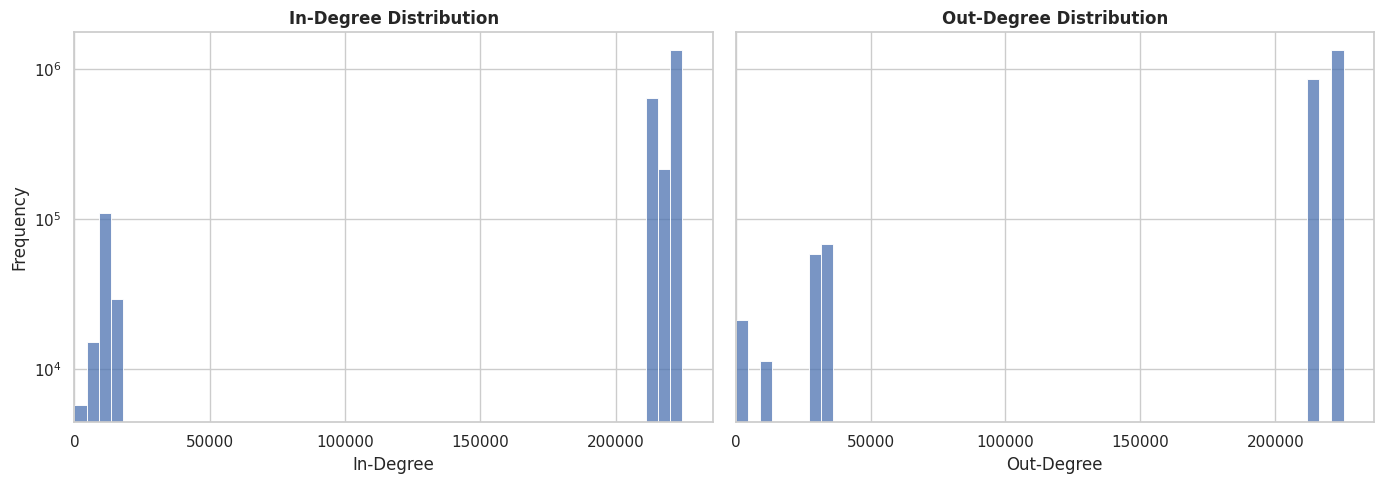

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

out_degree = dataset['IPV4_SRC_ADDR'].value_counts().rename('out_degree')
in_degree = dataset['IPV4_DST_ADDR'].value_counts().rename('in_degree')
ip_degrees = pd.concat([out_degree, in_degree], axis=1)
ip_degrees = ip_degrees.fillna(0).astype(int)
ip_degrees['total_degree'] = ip_degrees['out_degree'] + ip_degrees['in_degree']

ip_degrees.index.name = 'IP_Address'
dataset['out_degree'] = dataset['IPV4_SRC_ADDR'].map(ip_degrees['out_degree'])
dataset['in_degree'] = dataset['IPV4_DST_ADDR'].map(ip_degrees['in_degree'])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 1. Plot In-Degree on the left
sns.histplot(data=dataset, x='in_degree', bins=50, ax=axes[0])
axes[0].set_title("In-Degree Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, )
axes[0].set_xlabel("In-Degree")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale('log') # Log the Y-axis so small counts are visible

# 2. Plot Out-Degree on the right
sns.histplot(data=dataset, x='out_degree', bins=50, ax=axes[1])
axes[1].set_title("Out-Degree Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlim(0, )
axes[1].set_xlabel("Out-Degree")
axes[1].set_yscale('log') 

plt
plt.tight_layout()
plt.show()

In [86]:
import pandas as pd
import ipaddress

# 1. Define your subnets using the ipaddress module
# strict=False allows us to pass host bits without throwing an error
subnet_dict = {
    '10.40.85.0/28': ipaddress.ip_network('10.40.85.0/28', strict=False),
    '10.40.182.0/24': ipaddress.ip_network('10.40.182.0/24', strict=False),
    '10.40.198.10/32': ipaddress.ip_network('10.40.198.10/32', strict=False),
    '59.166.0.0/28': ipaddress.ip_network('59.166.0.0/28', strict=False),
    '127.0.0.1/32': ipaddress.ip_network('127.0.0.1/32', strict=False),
    '149.171.126.0/27': ipaddress.ip_network('149.171.126.0/27', strict=False),
    '175.45.176.0/30': ipaddress.ip_network('175.45.176.0/30', strict=False),
    '192.168.241.0/24': ipaddress.ip_network('192.168.241.0/24', strict=False),
    '224.0.0.5/32': ipaddress.ip_network('224.0.0.5/32', strict=False)
}

# 2. Create a fast mapping function
def assign_subnet(ip_string):
    try:
        ip = ipaddress.ip_address(ip_string)
        for subnet_name, network in subnet_dict.items():
            if ip in network:
                return subnet_name
    except ValueError:
        pass # Handles malformed IPs gracefully
    return 'Other/External'

# 3. Apply mapping to your dataset
# (Assuming your dataframe is named 'dataset')
dataset['Src_Subnet'] = dataset['IPV4_SRC_ADDR'].apply(assign_subnet)
dataset['Dst_Subnet'] = dataset['IPV4_DST_ADDR'].apply(assign_subnet)

# 4. To get a holistic view, let's look at flows where the subnet is the SOURCE
src_summary = dataset.groupby('Src_Subnet')['Label'].value_counts(normalize=True).unstack(fill_value=0)

# Multiply by 100 and round to make it readable as percentages
src_summary = (src_summary * 100).round(2)

# Rename columns for clarity
src_summary.columns = ['Benign (%)', 'Attack (%)']
src_summary['Total Flow Count'] = dataset['Src_Subnet'].value_counts()

In [89]:
src_summary = src_summary.sort_values(by="Total Flow Count", ascending=False)
print("Traffic Distribution by Source Subnet:")
print(src_summary)

Traffic Distribution by Source Subnet:
                  Benign (%)  Attack (%)  Total Flow Count
Src_Subnet                                                
59.166.0.0/28          100.0         0.0           2205164
175.45.176.0/30          0.0       100.0            127693
149.171.126.0/27       100.0         0.0             30696
10.40.85.0/28          100.0         0.0              1144
10.40.182.0/24         100.0         0.0               700
192.168.241.0/24       100.0         0.0                26
127.0.0.1/32           100.0         0.0                 1


In [ ]:
dataset['flow_start_time'] = pd.to_datetime(dataset['FLOW_START_MILLISECONDS'], unit='ms', cache=True)
dataset['flow_end_time'] = pd.to_datetime(dataset['FLOW_END_MILLISECONDS'], unit='ms', cache=True)

dataset.sample(10)

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack,flow_start_time,flow_end_time
1447344,1421935402458,1421935402503,59.166.0.8,14483,149.171.126.4,12591,6,36.0,5486,96,...,0,0,0,2,0,0,0,Benign,2015-01-22 14:03:22.458,2015-01-22 14:03:22.503
187470,1424234152653,1424234153120,59.166.0.3,48762,149.171.126.7,3298,6,11.0,5120,28,...,17,29,0,145,15,28,0,Benign,2015-02-18 04:35:52.653,2015-02-18 04:35:53.120
1781219,1421948864823,1421948864824,59.166.0.8,59315,149.171.126.6,53,17,5.0,130,2,...,0,0,0,0,0,0,0,Benign,2015-01-22 17:47:44.823,2015-01-22 17:47:44.824
1077673,1424250144078,1424250145276,59.166.0.8,38632,149.171.126.9,80,6,7.0,1684,14,...,91,264,0,1000,70,234,0,Benign,2015-02-18 09:02:24.078,2015-02-18 09:02:25.276
430368,1424251214433,1424251214631,175.45.176.0,61472,149.171.126.11,80,6,7.0,826,10,...,20,27,0,166,37,64,1,Exploits,2015-02-18 09:20:14.433,2015-02-18 09:20:14.631
270422,1424246945124,1424246945125,59.166.0.7,58305,149.171.126.4,53,17,5.0,146,2,...,0,0,0,0,0,0,0,Benign,2015-02-18 08:09:05.124,2015-02-18 08:09:05.125
1607102,1421941939641,1421941939661,149.171.126.6,41330,59.166.0.6,35062,6,36.0,7334,11,...,1,2,0,8,1,3,0,Benign,2015-01-22 15:52:19.641,2015-01-22 15:52:19.661
1741449,1421947343953,1421947345834,59.166.0.8,33423,149.171.126.3,21,6,1.0,2383,43,...,38,81,0,360,40,82,0,Benign,2015-01-22 17:22:23.953,2015-01-22 17:22:25.834
903113,1424244831276,1424244831277,59.166.0.9,57189,149.171.126.7,53,17,5.0,130,2,...,0,0,0,0,0,0,0,Benign,2015-02-18 07:33:51.276,2015-02-18 07:33:51.277
986370,1424258562086,1424258562103,59.166.0.1,29322,149.171.126.4,27303,6,36.0,2542,40,...,0,0,0,2,0,0,0,Benign,2015-02-18 11:22:42.086,2015-02-18 11:22:42.103


In [ ]:
dataset['flow_duration'] = (dataset['flow_end_time'] - dataset['flow_start_time'])
dataset['duration_seconds'] = dataset['flow_duration'].dt.total_seconds()

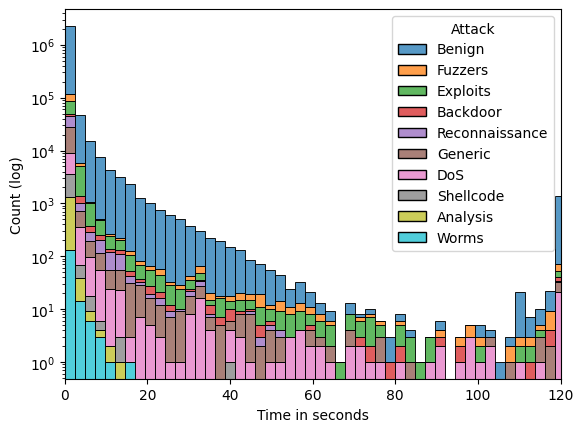

In [ ]:
sns.histplot(data=dataset, x='duration_seconds', hue='Attack', multiple='stack', bins=50)
plt.xlim(0, 120)
plt.yscale('log')
plt.xlabel('Time in seconds')
plt.ylabel('Count (log)')
plt.show()

In [ ]:
dataset.set_index('flow_start_time', inplace=True)
dataset.sort_index(inplace=True)

In [ ]:
flow_counts = dataset.resample('1s').size()
avg_duration = dataset['duration_seconds'].resample('1s').mean()

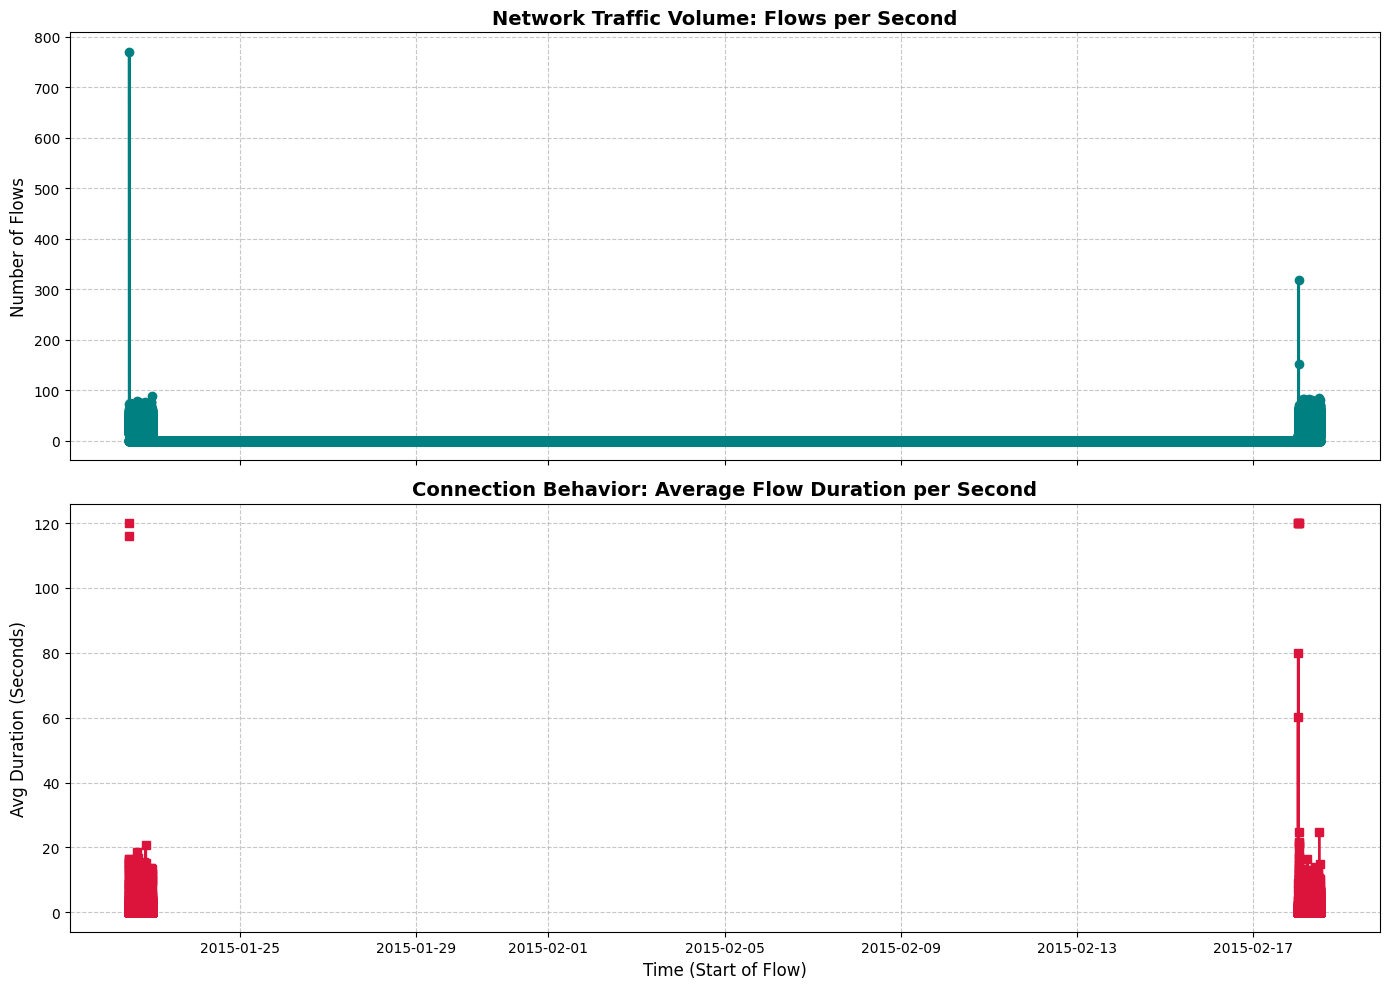

In [ ]:
fix, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top Plot: Total Flows over time
axes[0].plot(flow_counts.index, flow_counts.values, color='teal', linewidth=2, marker='o')
axes[0].set_title('Network Traffic Volume: Flows per Second', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Flows', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Bottom Plot: Average Duration over time
axes[1].plot(avg_duration.index, avg_duration.values, color='crimson', linewidth=2, marker='s')
axes[1].set_title('Connection Behavior: Average Flow Duration per Second', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Duration (Seconds)', fontsize=12)
axes[1].set_xlabel('Time (Start of Flow)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

There are two timeframes captured. We will isolate each and perform the same analysis on it.

In [ ]:
time_gaps = dataset.index.to_series().diff()
major_gap_indices = dataset[time_gaps > pd.Timedelta(days=1)].index

split_index = major_gap_indices[0]
block_1 = dataset[dataset.index < split_index]
block_2 = dataset[dataset.index >= split_index]

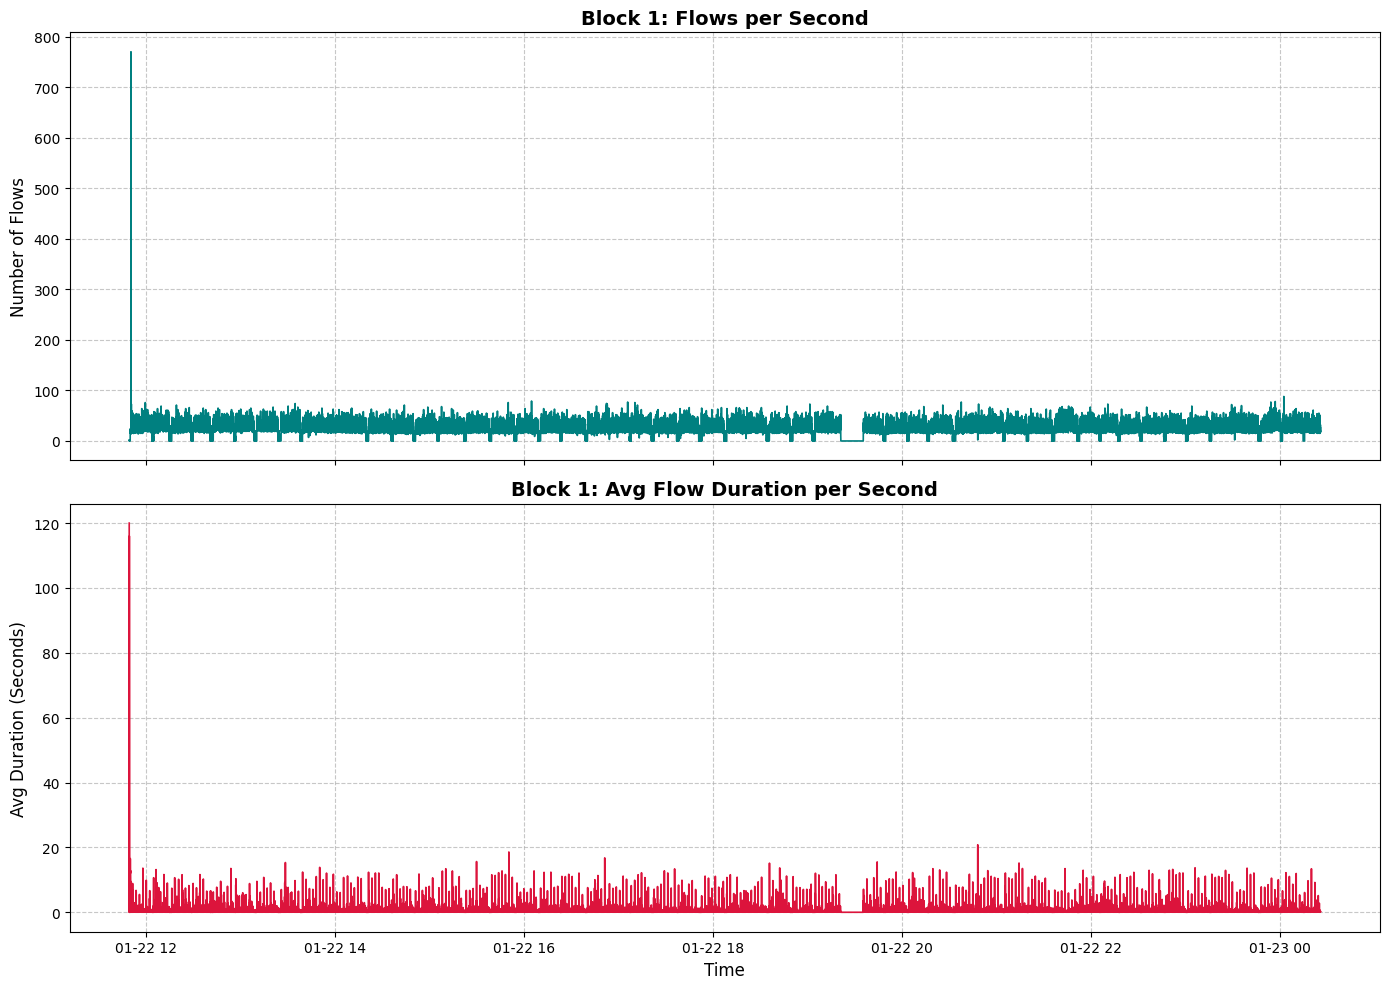

In [ ]:
block1_counts = block_1.resample('1s').size()
block1_duration = block_1['duration_seconds'].resample('1s').mean().fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Total Flows over time
axes[0].plot(block1_counts.index, block1_counts.values, color='teal', linewidth=1.2)
axes[0].set_title('Block 1: Flows per Second', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Flows', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Average Duration over time
axes[1].plot(block1_duration.index, block1_duration.values, color='crimson', linewidth=1.2)
axes[1].set_title('Block 1: Avg Flow Duration per Second', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Duration (Seconds)', fontsize=12)
axes[1].set_xlabel('Time', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

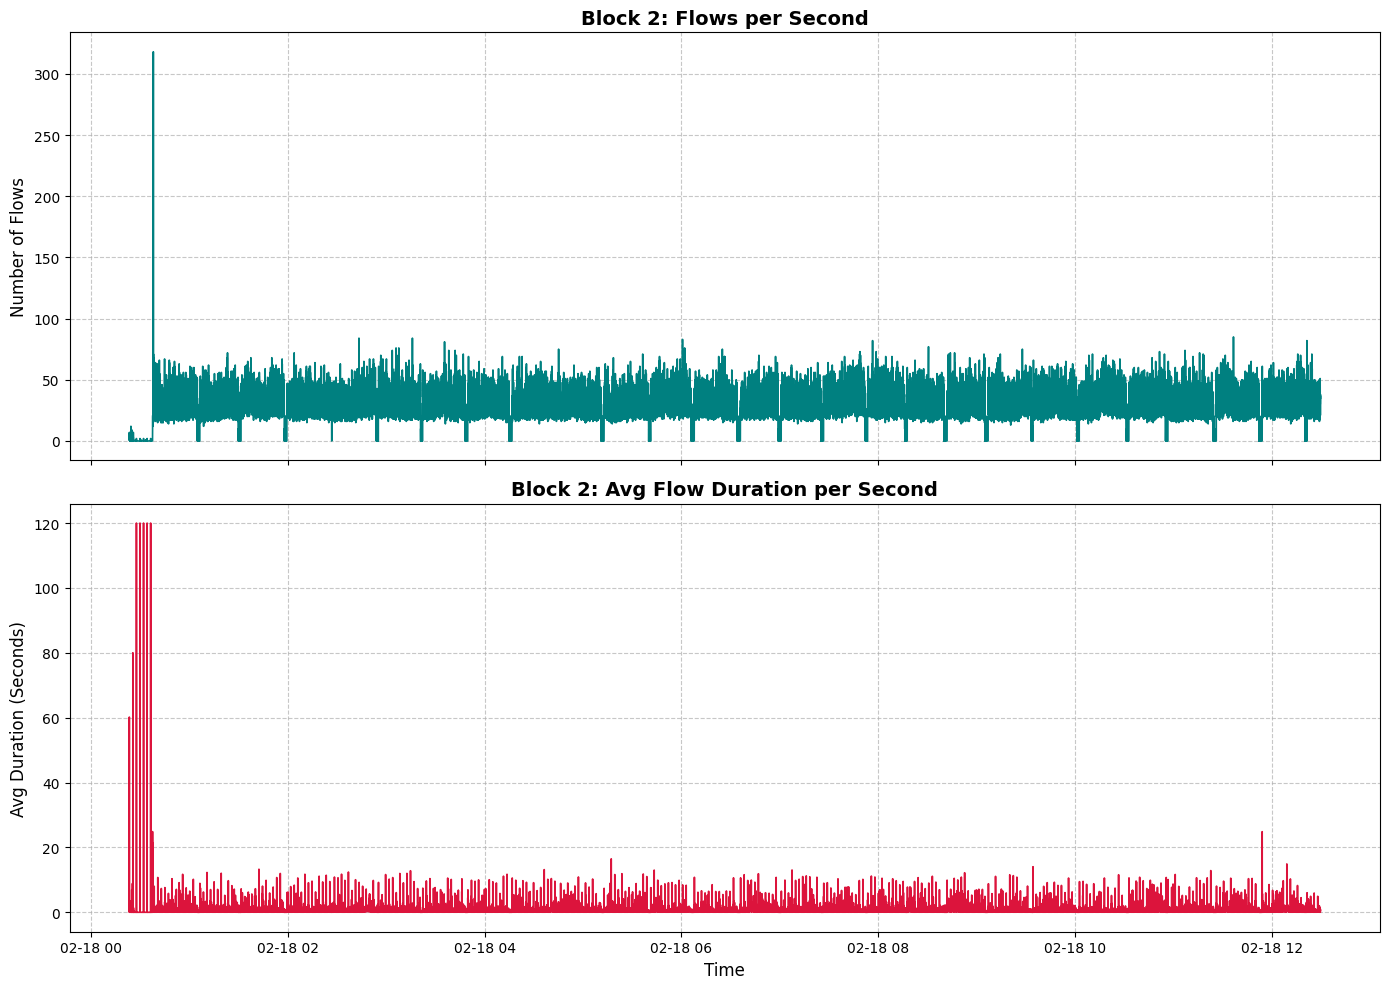

In [ ]:
block2_counts = block_2.resample('1s').size()
block2_duration = block_2['duration_seconds'].resample('1s').mean().fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Total Flows over time
axes[0].plot(block2_counts.index, block2_counts.values, color='teal', linewidth=1.2)
axes[0].set_title('Block 2: Flows per Second', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Flows', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Average Duration over time
axes[1].plot(block2_duration.index, block2_duration.values, color='crimson', linewidth=1.2)
axes[1].set_title('Block 2: Avg Flow Duration per Second', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Duration (Seconds)', fontsize=12)
axes[1].set_xlabel('Time', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Run FFT
Analyse time series data using periocidy, trend, etc.

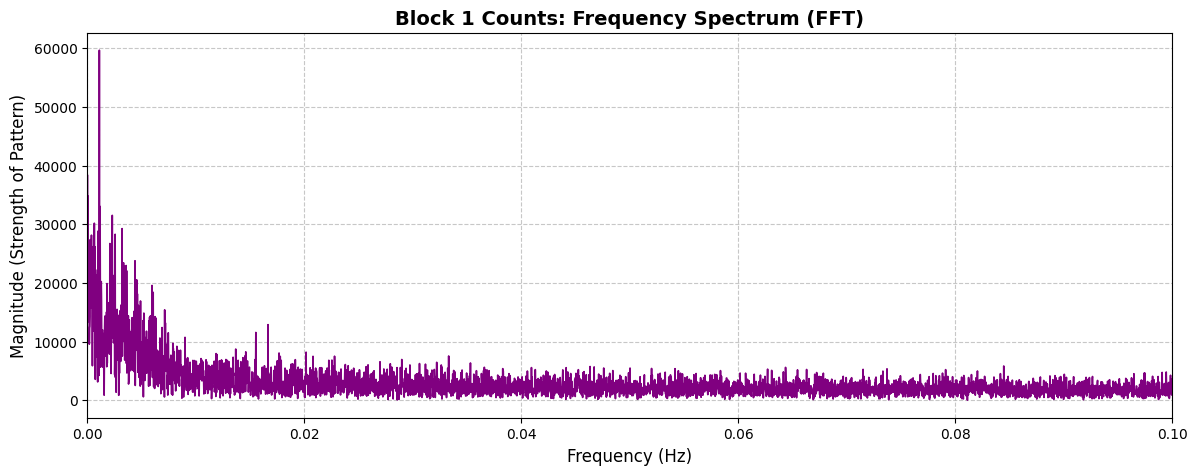

In [ ]:
signal = block1_counts.values

# remove oscillation spike.
signal_centered = signal - np.mean(signal)

n = len(signal_centered)
sampling_rate = 1.0
fft_values = np.fft.fft(signal_centered)
fft_freqs = np.fft.fftfreq(n, d=1/sampling_rate)

# filter for positive freq
positive_freqs = fft_freqs[:n//2]
positive_magnitudes = np.abs(fft_values)[:n//2]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(positive_freqs, positive_magnitudes, color='purple', linewidth=1.2)
ax.set_title('Block 1 Counts: Frequency Spectrum (FFT)', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Magnitude (Strength of Pattern)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(0, 0.1)
plt.show()

## Graph EDA

In [ ]:
#obtain ip, port, and (ip, port) dst and src counts
#TOOD: Add non-ordered set -> AB=BA
num_dst_ip = dataset['IPV4_DST_ADDR'].n_unique()
num_src_ip = dataset['IPV4_SRC_ADDR'].n_unique()
print(f'IP Address:\ndst: {num_dst_ip}, src: {num_src_ip}, total:{num_dst_ip + num_src_ip}')

num_dst_port = dataset['L4_DST_PORT'].n_unique()
num_src_port = dataset['L4_SRC_PORT'].n_unique()
print(f'Port:\ndst: {num_dst_port}, src: {num_src_port}, total:{num_dst_port + num_src_port}')

num_dst_ip_port = dataset.unique(['IPV4_DST_ADDR', 'L4_DST_PORT']).height
num_src_ip_port = dataset.unique(['IPV4_SRC_ADDR', 'L4_SRC_PORT']).height
print(f'(IP, Port):\ndst: {num_dst_ip_port}, src: {num_src_ip_port}, total:{num_dst_ip_port + num_src_ip_port}')

IP Address:
dst: 40, src: 40, total:80
Port:
dst: 64617, src: 64597, total:129214
(IP, Port):
dst: 410955, src: 686046, total:1097001


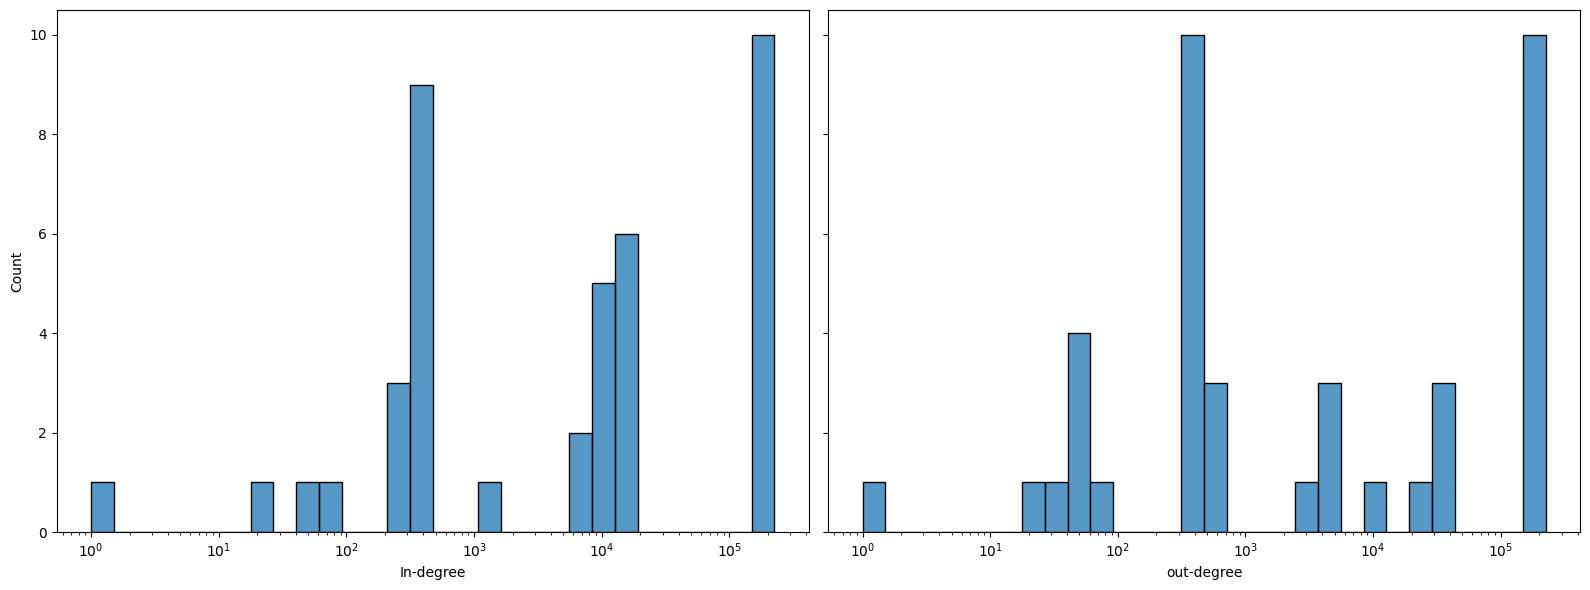

In [ ]:
in_dist = dataset['IPV4_DST_ADDR'].value_counts().select(pl.col("count").alias("degree"))
out_dist = dataset['IPV4_SRC_ADDR'].value_counts().select(pl.col("count").alias("degree"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.histplot(in_dist["degree"].to_numpy(), ax=axes[0], bins=30, log_scale=True, edgecolor='black')
axes[0].set_xlabel('In-degree')

sns.histplot(out_dist["degree"].to_numpy(), ax=axes[1], bins=30, log_scale=True, edgecolor='black')
axes[1].set_xlabel('out-degree')

plt.tight_layout()
plt.show()

In [ ]:
dataset.columns

['FLOW_START_MILLISECONDS',
 'FLOW_END_MILLISECONDS',
 'IPV4_SRC_ADDR',
 'L4_SRC_PORT',
 'IPV4_DST_ADDR',
 'L4_DST_PORT',
 'PROTOCOL',
 'L7_PROTO',
 'IN_BYTES',
 'IN_PKTS',
 'OUT_BYTES',
 'OUT_PKTS',
 'TCP_FLAGS',
 'CLIENT_TCP_FLAGS',
 'SERVER_TCP_FLAGS',
 'FLOW_DURATION_MILLISECONDS',
 'DURATION_IN',
 'DURATION_OUT',
 'MIN_TTL',
 'MAX_TTL',
 'LONGEST_FLOW_PKT',
 'SHORTEST_FLOW_PKT',
 'MIN_IP_PKT_LEN',
 'MAX_IP_PKT_LEN',
 'SRC_TO_DST_SECOND_BYTES',
 'DST_TO_SRC_SECOND_BYTES',
 'RETRANSMITTED_IN_BYTES',
 'RETRANSMITTED_IN_PKTS',
 'RETRANSMITTED_OUT_BYTES',
 'RETRANSMITTED_OUT_PKTS',
 'SRC_TO_DST_AVG_THROUGHPUT',
 'DST_TO_SRC_AVG_THROUGHPUT',
 'NUM_PKTS_UP_TO_128_BYTES',
 'NUM_PKTS_128_TO_256_BYTES',
 'NUM_PKTS_256_TO_512_BYTES',
 'NUM_PKTS_512_TO_1024_BYTES',
 'NUM_PKTS_1024_TO_1514_BYTES',
 'TCP_WIN_MAX_IN',
 'TCP_WIN_MAX_OUT',
 'ICMP_TYPE',
 'ICMP_IPV4_TYPE',
 'DNS_QUERY_ID',
 'DNS_QUERY_TYPE',
 'DNS_TTL_ANSWER',
 'FTP_COMMAND_RET_CODE',
 'SRC_TO_DST_IAT_MIN',
 'SRC_TO_DST_IAT_MAX',
 

## GraphIDS Dataset Analysis
TODO - Move to chronologically correct version from PPT-GNN.

In [1]:
!pip uninstall community -y
!pip install torch_geometric python-louvain

In [2]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/MyDrive/GraphIDS

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/MyDrive/GraphIDS


In [28]:
import polars as pl
import networkx as nx
import torch
from torch_geometric.utils import from_networkx
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from scipy.stats import variation
from tqdm import tqdm

# ── Column aliases ────────────────────────────────────────────────────────────
SRC      = 'IPV4_SRC_ADDR'
DST      = 'IPV4_DST_ADDR'
LABEL    = 'Label'
ATTACK   = 'Attack'
TIME_COL = 'FLOW_START_MILLISECONDS'
DELTA_MS = 5_000

# ── Snapshot builder ──────────────────────────────────────────────────────────
def build_snapshot(df: pl.DataFrame) -> nx.DiGraph:
    return nx.from_pandas_edgelist(
        df.select([SRC, DST, LABEL]).to_pandas(),
        source=SRC, target=DST,
        edge_attr=LABEL, create_using=nx.DiGraph()
    )

# ── Detect the gap ────────────────────────────────────────────────────────────
snap_counts = (
    dataset.with_columns(
        (((pl.col(TIME_COL) - dataset[TIME_COL].min()) / DELTA_MS)
         .cast(pl.Int64))
        .alias('snapshot_id')
    )
    .group_by('snapshot_id')
    .agg(pl.len().alias('flows'))
    .sort('snapshot_id')
)

gaps = (
    snap_counts
    .with_columns(
        (pl.col('snapshot_id') - pl.col('snapshot_id').shift(1)).alias('gap')
    )
    .filter(pl.col('gap') > 1000)
    .sort('gap', descending=True)
)
print("Large gaps detected:")
print(gaps.head())

split_sid  = gaps['snapshot_id'][0]
ts_min_all = dataset[TIME_COL].min()
split_ts   = ts_min_all + split_sid * DELTA_MS
print(f"\nSplitting at snapshot_id {split_sid} "
      f"(t = {split_sid * DELTA_MS / 1000:.0f}s from start)")

# ── Split & re-index each day from 0 ─────────────────────────────────────────
def make_day(df: pl.DataFrame, ts_min: int) -> pl.DataFrame:
    return (
        df.with_columns(
            (((pl.col(TIME_COL) - ts_min) / DELTA_MS)
             .cast(pl.Int64))
            .alias('snapshot_id')
        )
    )

raw_day1 = dataset.filter(pl.col(TIME_COL) <  split_ts)
raw_day2 = dataset.filter(pl.col(TIME_COL) >= split_ts)

ts_min1  = raw_day1[TIME_COL].min()
ts_min2  = raw_day2[TIME_COL].min()

day1 = make_day(raw_day1, ts_min1)
day2 = make_day(raw_day2, ts_min2)

# ── Build snapshot dicts ──────────────────────────────────────────────────────
def build_snapshots(df: pl.DataFrame) -> dict:
    snaps = {}
    for sid in df['snapshot_id'].unique().sort().to_list():
        snaps[sid] = build_snapshot(df.filter(pl.col('snapshot_id') == sid))
    return snaps

print("Building day 1 snapshots...")
snapshots1 = build_snapshots(day1)
print("Building day 2 snapshots...")
snapshots2 = build_snapshots(day2)

# ── Aggregate graphs per day ──────────────────────────────────────────────────
G1     = build_snapshot(raw_day1)
G2     = build_snapshot(raw_day2)
G1_und = G1.to_undirected()
G2_und = G2.to_undirected()

# ── Convenience dict — all subsequent cells iterate over this ─────────────────
days = {
    'Day 1': dict(df=day1, raw=raw_day1, snaps=snapshots1,
                  G=G1, G_und=G1_und, ts_min=ts_min1),
    'Day 2': dict(df=day2, raw=raw_day2, snaps=snapshots2,
                  G=G2, G_und=G2_und, ts_min=ts_min2),
}

for name, d in days.items():
    snap_ids = sorted(d['snaps'].keys())
    print(f"\n{name}:")
    print(f"  Flows     : {len(d['df']):,}")
    print(f"  Snapshots : {len(snap_ids)}")
    print(f"  Duration  : {(snap_ids[-1] - snap_ids[0]) * DELTA_MS / 1000:.0f}s")
    print(f"  Nodes     : {d['G'].number_of_nodes()}")
    print(f"  Edges     : {d['G'].number_of_edges()}")

Large gaps detected:
shape: (1, 3)
┌─────────────┬───────┬────────┐
│ snapshot_id ┆ flows ┆ gap    │
│ ---         ┆ ---   ┆ ---    │
│ i64         ┆ u32   ┆ i64    │
╞═════════════╪═══════╪════════╡
│ 458326      ┆ 17    ┆ 449257 │
└─────────────┴───────┴────────┘

Splitting at snapshot_id 458326 (t = 2291630s from start)
Building day 1 snapshots...
Building day 2 snapshots...

Day 1:
  Flows     : 1,135,352
  Snapshots : 8633
  Duration  : 45345s
  Nodes     : 40
  Edges     : 283

Day 2:
  Flows     : 1,230,072
  Snapshots : 8412
  Duration  : 43555s
  Nodes     : 42
  Edges     : 259



Day 1:
  Total flows : 1,135,352
  Benign      : 1,117,890  (98.5%)
  Attack      : 17,462  (1.5%)
  Elevated snapshots (>2× baseline): 1196 / 8633
shape: (10, 3)
┌────────────────┬─────────┬───────┐
│ Attack         ┆ count   ┆ pct   │
│ ---            ┆ ---     ┆ ---   │
│ str            ┆ u32     ┆ f64   │
╞════════════════╪═════════╪═══════╡
│ Benign         ┆ 1117890 ┆ 98.46 │
│ Fuzzers        ┆ 6046    ┆ 0.53  │
│ Exploits       ┆ 5622    ┆ 0.5   │
│ Generic        ┆ 2405    ┆ 0.21  │
│ Reconnaissance ┆ 2155    ┆ 0.19  │
│ DoS            ┆ 624     ┆ 0.05  │
│ Shellcode      ┆ 280     ┆ 0.02  │
│ Analysis       ┆ 267     ┆ 0.02  │
│ Backdoor       ┆ 43      ┆ 0.0   │
│ Worms          ┆ 20      ┆ 0.0   │
└────────────────┴─────────┴───────┘

Day 2:
  Total flows : 1,230,072
  Benign      : 1,119,841  (91.0%)
  Attack      : 110,231  (9.0%)
  Elevated snapshots (>2× baseline): 388 / 8412
shape: (10, 3)
┌────────────────┬─────────┬───────┐
│ Attack         ┆ count   ┆ pct   │
│ --- 

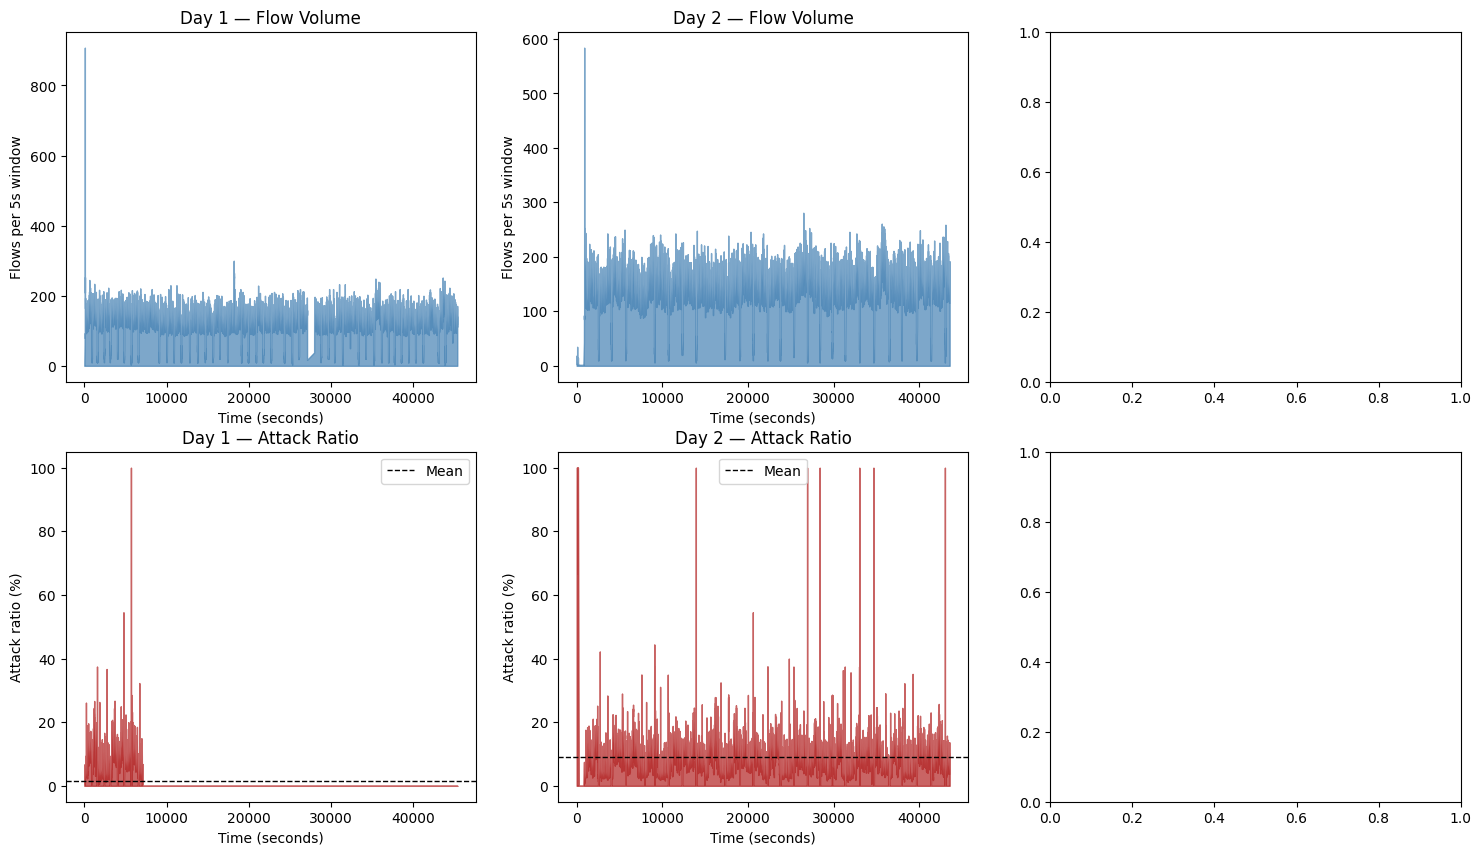

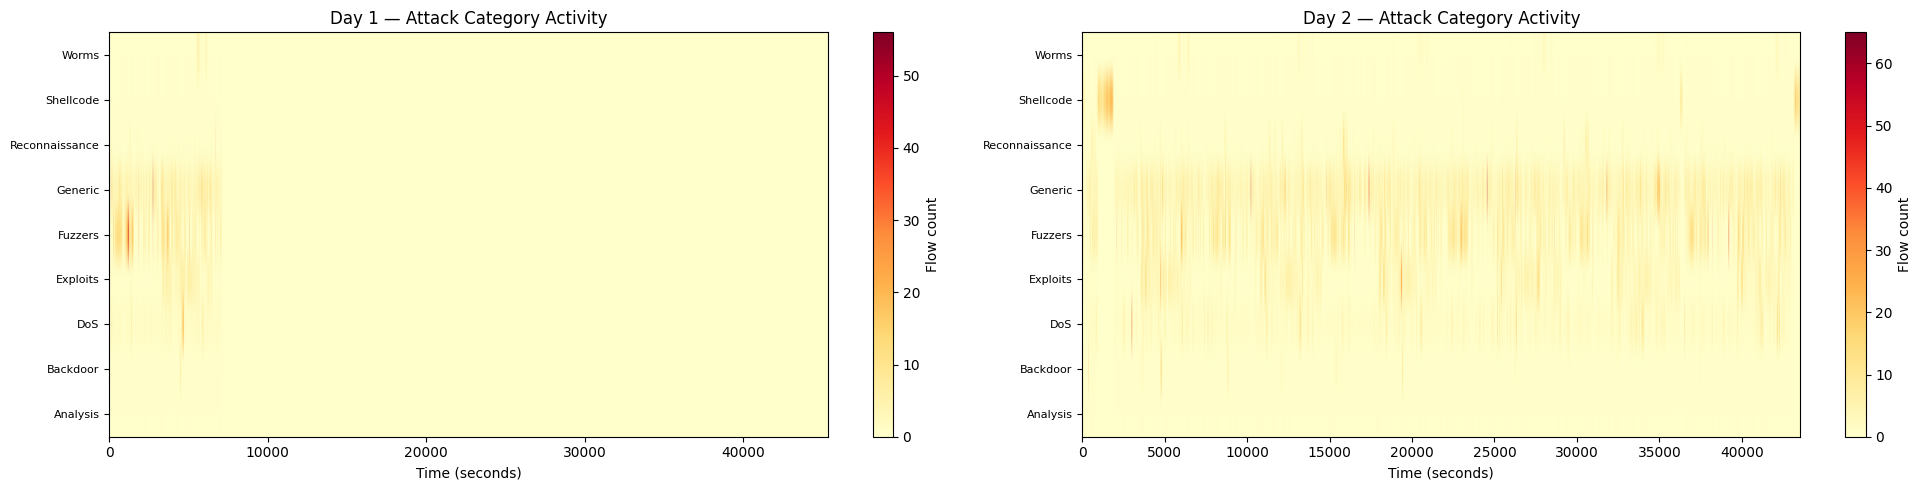

In [29]:
def with_pct(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        (pl.col('count') / df['count'].sum() * 100).round(2).alias('pct')
    )

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (name, d) in enumerate(days.items()):
    df     = d['df']
    snap_stats = (
        df.group_by('snapshot_id')
        .agg([pl.len().alias('flows'),
              pl.col(LABEL).mean().alias('attack_ratio')])
        .sort('snapshot_id')
    )
    t      = snap_stats['snapshot_id'].to_numpy() * DELTA_MS / 1000
    flows  = snap_stats['flows'].to_numpy()
    ar     = snap_stats['attack_ratio'].to_numpy()

    # Flow volume
    axes[0, col].fill_between(t, flows, alpha=0.7, color='steelblue')
    axes[0, col].set_title(f'{name} — Flow Volume')
    axes[0, col].set_ylabel('Flows per 5s window')
    axes[0, col].set_xlabel('Time (seconds)')

    # Attack ratio
    axes[1, col].fill_between(t, ar * 100, alpha=0.7, color='firebrick')
    axes[1, col].axhline(df[LABEL].mean() * 100, color='black',
                         linestyle='--', linewidth=1, label='Mean')
    axes[1, col].set_title(f'{name} — Attack Ratio')
    axes[1, col].set_ylabel('Attack ratio (%)')
    axes[1, col].set_xlabel('Time (seconds)')
    axes[1, col].legend()

    # Printed stats
    total = len(df)
    n_attack = df.filter(pl.col(LABEL) == 1).height
    print(f"\n{name}:")
    print(f"  Total flows : {total:,}")
    print(f"  Benign      : {total - n_attack:,}  "
          f"({(total-n_attack)/total*100:.1f}%)")
    print(f"  Attack      : {n_attack:,}  ({n_attack/total*100:.1f}%)")
    print(f"  Elevated snapshots (>2× baseline): "
          f"{snap_stats.filter(pl.col('attack_ratio') > df[LABEL].mean() * 2).height}"
          f" / {len(snap_stats)}")
    print(with_pct(df[ATTACK].value_counts().sort('count', descending=True)))

# Category heatmap — one per day
fig2, axes2 = plt.subplots(1, 2, figsize=(20, 5))
for ax, (name, d) in zip(axes2, days.items()):
    df = d['df']
    categories = (df.filter(pl.col(LABEL) == 1)[ATTACK]
                  .unique().sort().to_list())
    snap_ids   = sorted(d['snaps'].keys())
    cat_matrix = np.zeros((len(categories), len(snap_ids)))
    for j, sid in enumerate(snap_ids):
        sdf = df.filter(pl.col('snapshot_id') == sid)
        for i, cat in enumerate(categories):
            cat_matrix[i, j] = sdf.filter(pl.col(ATTACK) == cat).height
    t = np.array(snap_ids) * DELTA_MS / 1000
    im = ax.imshow(cat_matrix, aspect='auto', cmap='YlOrRd',
                   extent=[t.min(), t.max(), -0.5, len(categories)-0.5])
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(categories, fontsize=8)
    ax.set_xlabel('Time (seconds)')
    ax.set_title(f'{name} — Attack Category Activity')
    plt.colorbar(im, ax=ax, label='Flow count')

plt.tight_layout()
plt.show()

Day 1 centrality: 100%|██████████| 8633/8633 [00:33<00:00, 255.32it/s]


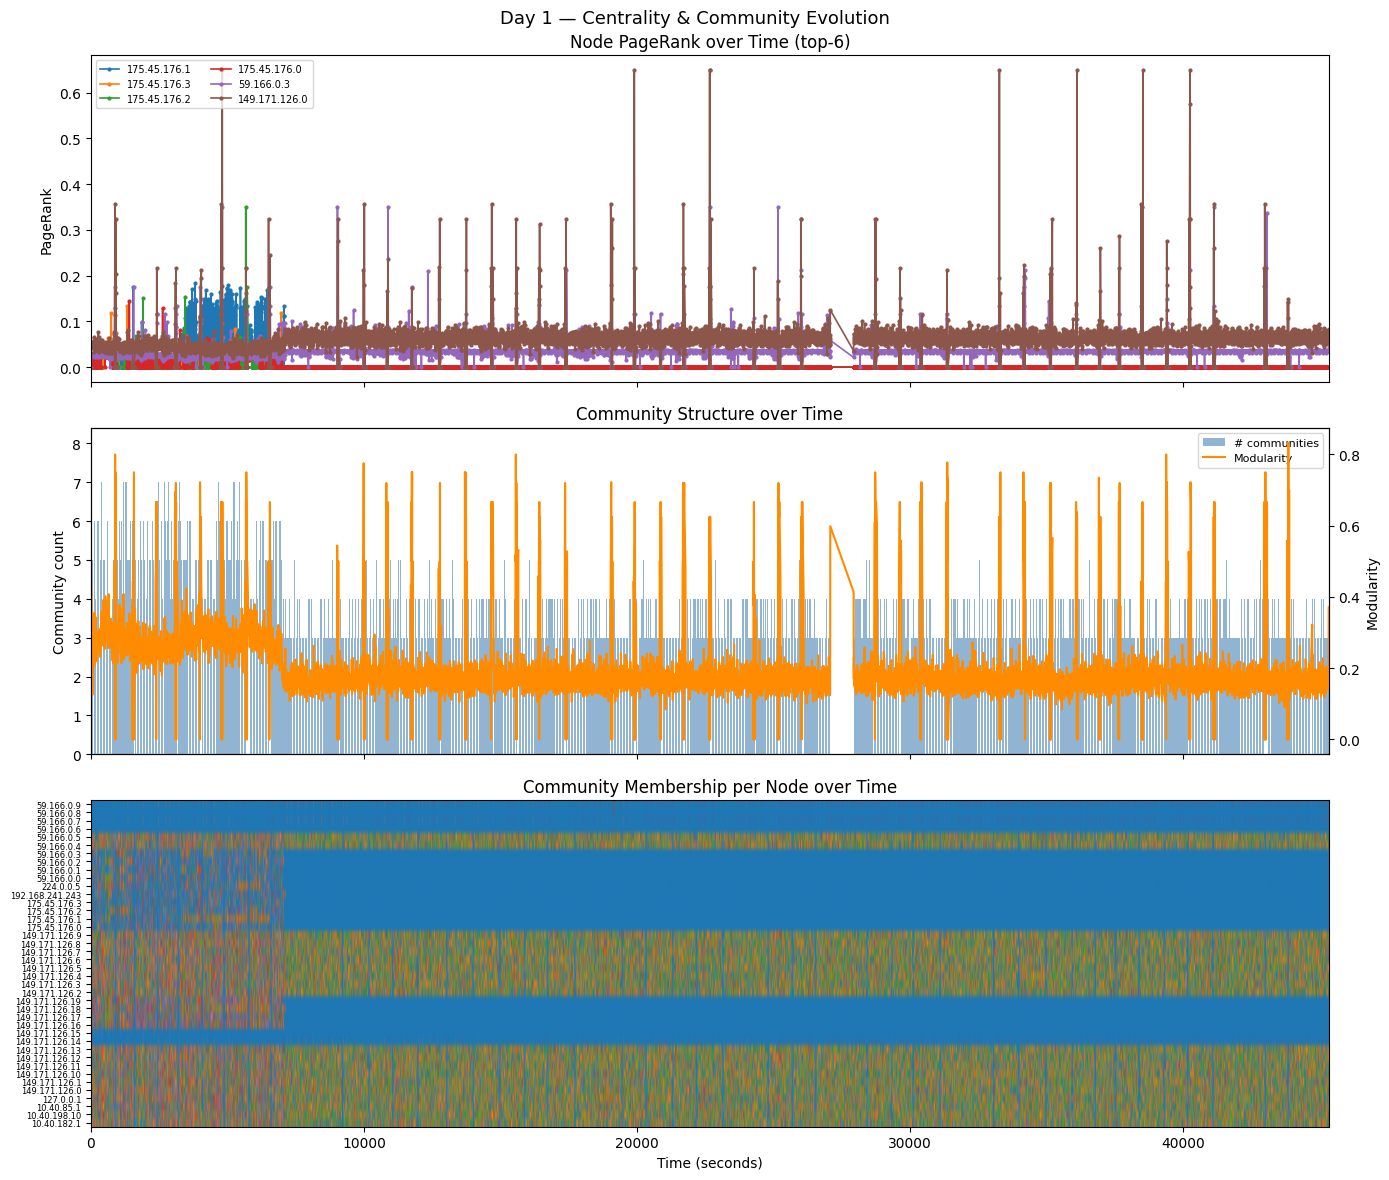


Day 1 — Community summary:
  Mean communities : 3.58
  Mean modularity  : 0.1981

Top-6 nodes by PageRank:
  175.45.176.1           PR=0.05437  in=10  out=10
  175.45.176.3           PR=0.05015  in=10  out=10
  175.45.176.2           PR=0.04145  in=9  out=10
  175.45.176.0           PR=0.04031  in=8  out=10
  59.166.0.3             PR=0.02678  in=10  out=10
  149.171.126.0          PR=0.02678  in=10  out=10


Day 2 centrality: 100%|██████████| 8412/8412 [00:38<00:00, 221.25it/s]


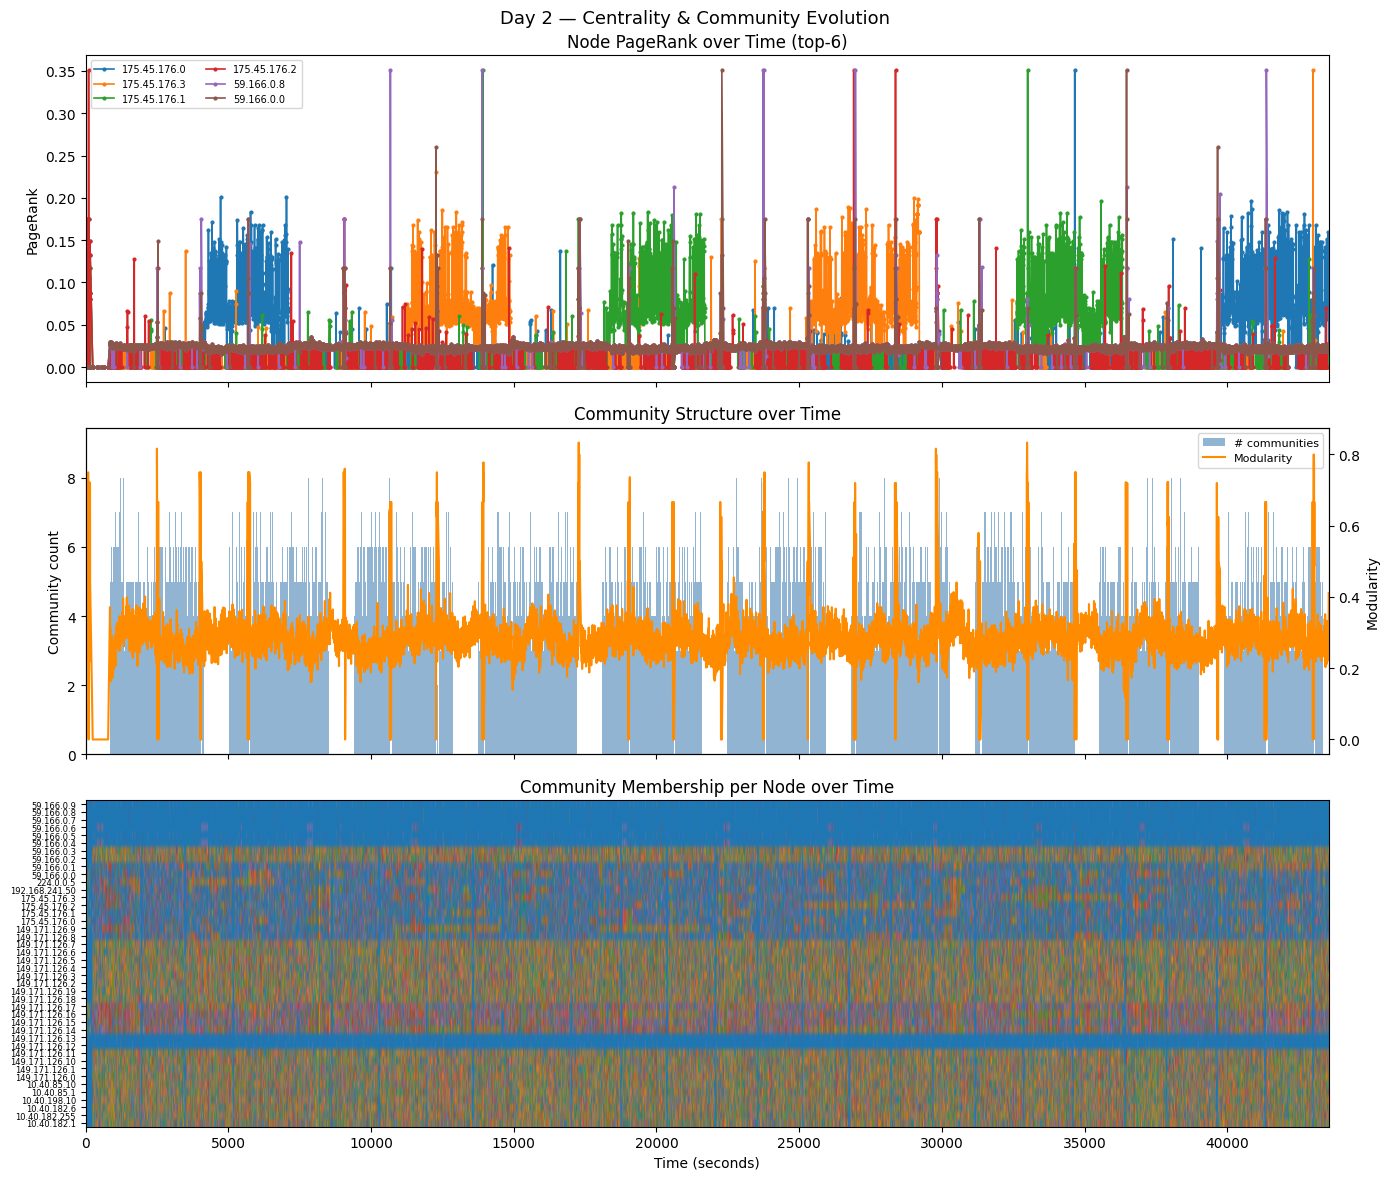


Day 2 — Community summary:
  Mean communities : 4.95
  Mean modularity  : 0.2875

Top-6 nodes by PageRank:
  175.45.176.0           PR=0.04804  in=11  out=10
  175.45.176.3           PR=0.04804  in=11  out=10
  175.45.176.1           PR=0.04804  in=11  out=10
  175.45.176.2           PR=0.04264  in=10  out=10
  59.166.0.8             PR=0.03532  in=9  out=10
  59.166.0.0             PR=0.03275  in=8  out=10


In [30]:
def analyse_centrality(name, d):
    snaps    = d['snaps']
    G        = d['G']
    G_und    = d['G_und']
    snap_ids = sorted(snaps.keys())
    all_nodes = sorted(G.nodes())
    node_idx  = {n: i for i, n in enumerate(all_nodes)}
    N = len(all_nodes)
    S = max(snap_ids) + 1

    pr_matrix    = np.zeros((S, N))
    comm_matrix  = np.full((S, N), -1, dtype=int)
    snap_n_comms = {}
    snap_mod     = {}

    for sid in tqdm(snap_ids, desc=f'{name} centrality', leave=True):
        G_t     = snaps[sid]
        G_t_und = G_t.to_undirected()
        pr_t    = nx.pagerank(G_t, alpha=0.85, max_iter=300)
        for node, score in pr_t.items():
            if node in node_idx:
                pr_matrix[sid, node_idx[node]] = score
        if G_t_und.number_of_nodes() > 1:
            comms = nx.community.louvain_communities(G_t_und, seed=42)
            part  = {node: i for i, c in enumerate(comms) for node in c}
            for node, comm in part.items():
                if node in node_idx:
                    comm_matrix[sid, node_idx[node]] = comm
            snap_n_comms[sid] = len(comms)
            snap_mod[sid]     = nx.community.modularity(G_t_und, comms)
        else:
            snap_n_comms[sid] = 1
            snap_mod[sid]     = 0.0

    agg_pr = nx.pagerank(G, alpha=0.85, max_iter=300)
    top6   = [n for n, _ in
              sorted(agg_pr.items(), key=lambda x: x[1], reverse=True)[:6]]
    t_axis = np.array(snap_ids) * DELTA_MS / 1000

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(f'{name} — Centrality & Community Evolution', fontsize=13)

    for node in top6:
        idx = node_idx[node]
        axes[0].plot(t_axis, pr_matrix[snap_ids, idx],
                     label=node, marker='o', markersize=2, linewidth=1.2)
    axes[0].set_ylabel('PageRank')
    axes[0].set_title('Node PageRank over Time (top-6)')
    axes[0].legend(fontsize=7, ncol=2)

    comm_counts = [snap_n_comms[s] for s in snap_ids]
    modularity  = [snap_mod[s]     for s in snap_ids]
    ax2b = axes[1].twinx()
    axes[1].bar(t_axis, comm_counts, width=DELTA_MS/1000*0.8,
                alpha=0.6, color='steelblue', label='# communities')
    ax2b.plot(t_axis, modularity, color='darkorange',
              linewidth=1.5, label='Modularity')
    axes[1].set_ylabel('Community count')
    ax2b.set_ylabel('Modularity')
    axes[1].set_title('Community Structure over Time')
    l1, lb1 = axes[1].get_legend_handles_labels()
    l2, lb2 = ax2b.get_legend_handles_labels()
    axes[1].legend(l1+l2, lb1+lb2, fontsize=8)

    comm_slice = comm_matrix[snap_ids, :]
    axes[2].imshow(comm_slice.T, aspect='auto', cmap='tab10',
                   extent=[t_axis.min(), t_axis.max(), -0.5, N-0.5],
                   vmin=0, vmax=9)
    axes[2].set_yticks(range(N))
    axes[2].set_yticklabels(all_nodes, fontsize=6)
    axes[2].set_xlabel('Time (seconds)')
    axes[2].set_title('Community Membership per Node over Time')

    plt.tight_layout()
    plt.show()

    print(f"\n{name} — Community summary:")
    print(f"  Mean communities : {np.mean(comm_counts):.2f}")
    print(f"  Mean modularity  : {np.mean(modularity):.4f}")
    print(f"\nTop-6 nodes by PageRank:")
    for node in top6:
        print(f"  {node:<22} PR={agg_pr[node]:.5f}  "
              f"in={G.in_degree(node)}  out={G.out_degree(node)}")

    return dict(pr_matrix=pr_matrix, comm_matrix=comm_matrix,
                snap_n_comms=snap_n_comms, snap_mod=snap_mod,
                node_idx=node_idx, all_nodes=all_nodes)

centrality_results = {}
for name, d in days.items():
    centrality_results[name] = analyse_centrality(name, d)


Day 1


Port Sweep:  25%|██▌       | 1/4 [00:00<00:01,  1.93it/s]


  Beaconing pairs : 3


Propagation:  75%|███████▌  | 3/4 [00:01<00:00,  3.03it/s]

  Port sweeps     : 2,337  avg attack ratio: 0.0%
  Bursts          : 269  avg attack ratio: 1.1%


Done: 100%|██████████| 4/4 [00:09<00:00,  2.26s/it, snapshot=8633/8633]


  Propagations    : 26,441


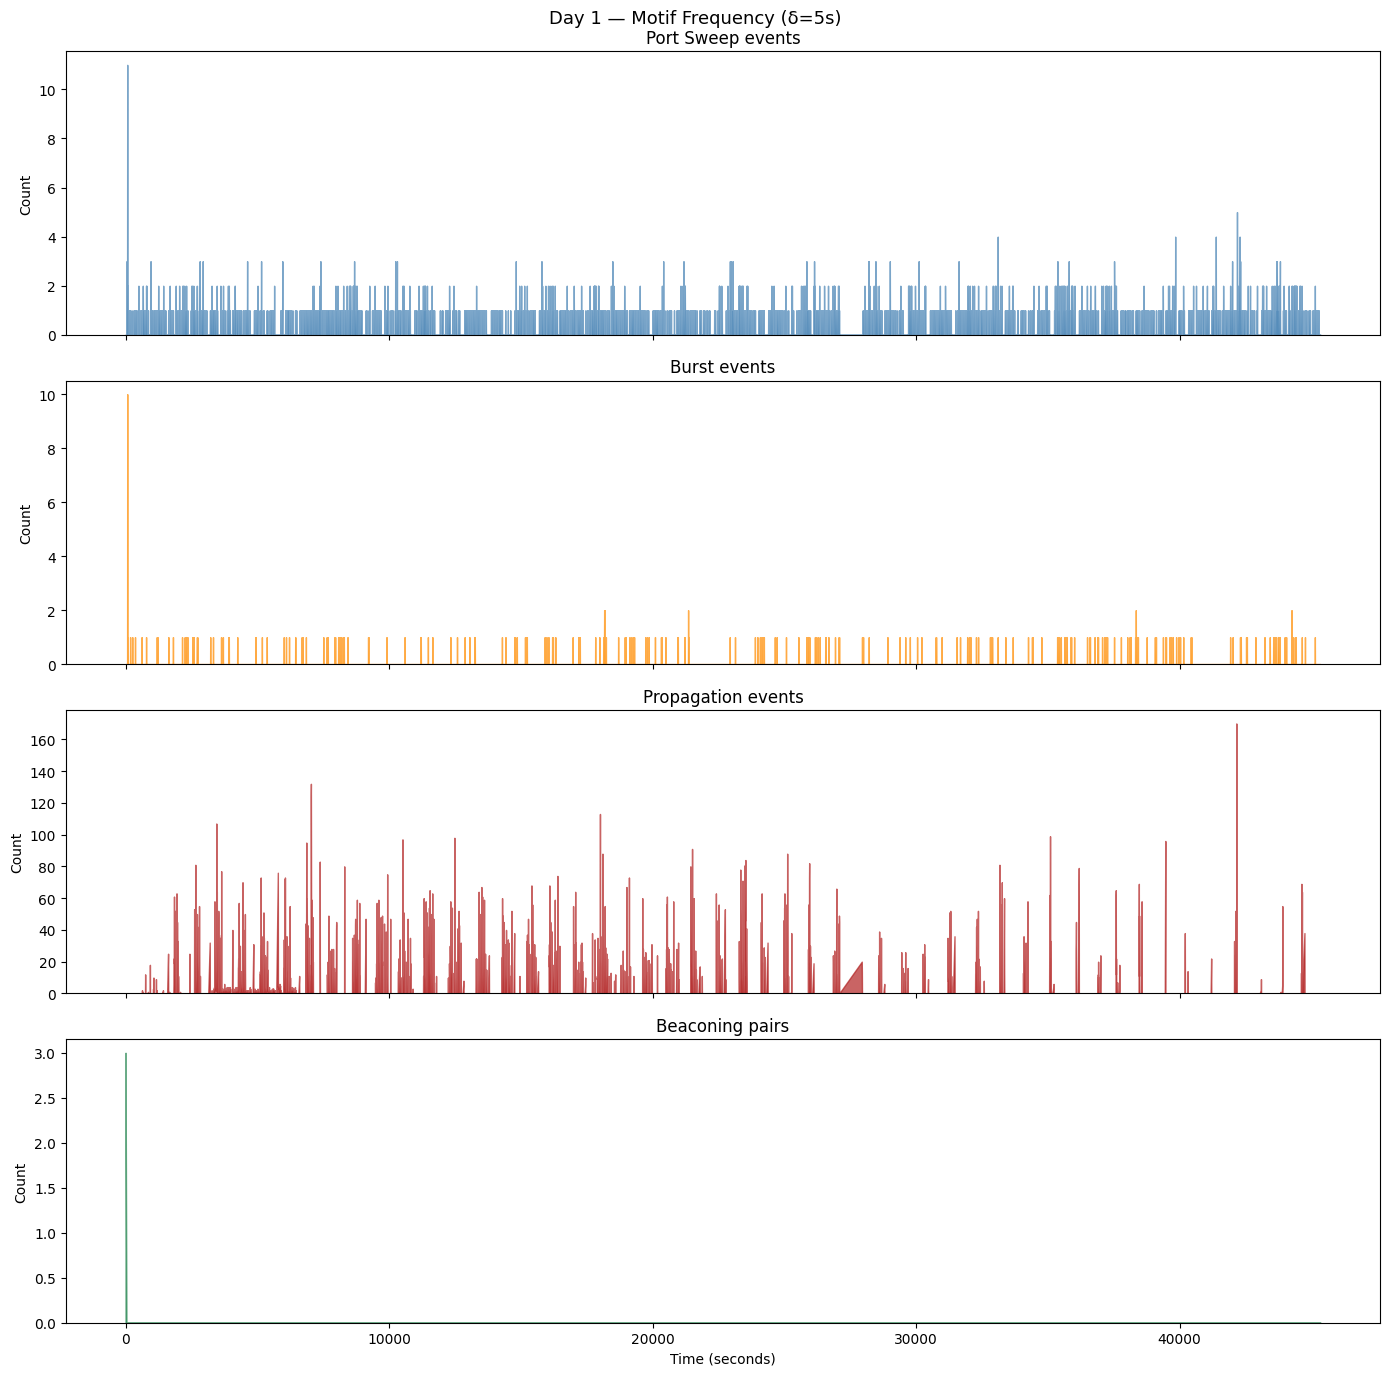


Day 2


Port Sweep:  25%|██▌       | 1/4 [00:00<00:02,  1.01it/s]


  Beaconing pairs : 7


Bursts:  50%|█████     | 2/4 [00:01<00:01,  1.05it/s]    

  Port sweeps     : 2,286  avg attack ratio: 0.0%


Propagation:  75%|███████▌  | 3/4 [00:02<00:00,  1.53it/s, snapshot=47/8412]

  Bursts          : 275  avg attack ratio: 6.2%


Done: 100%|██████████| 4/4 [00:09<00:00,  2.38s/it, snapshot=8412/8412]


  Propagations    : 7,756


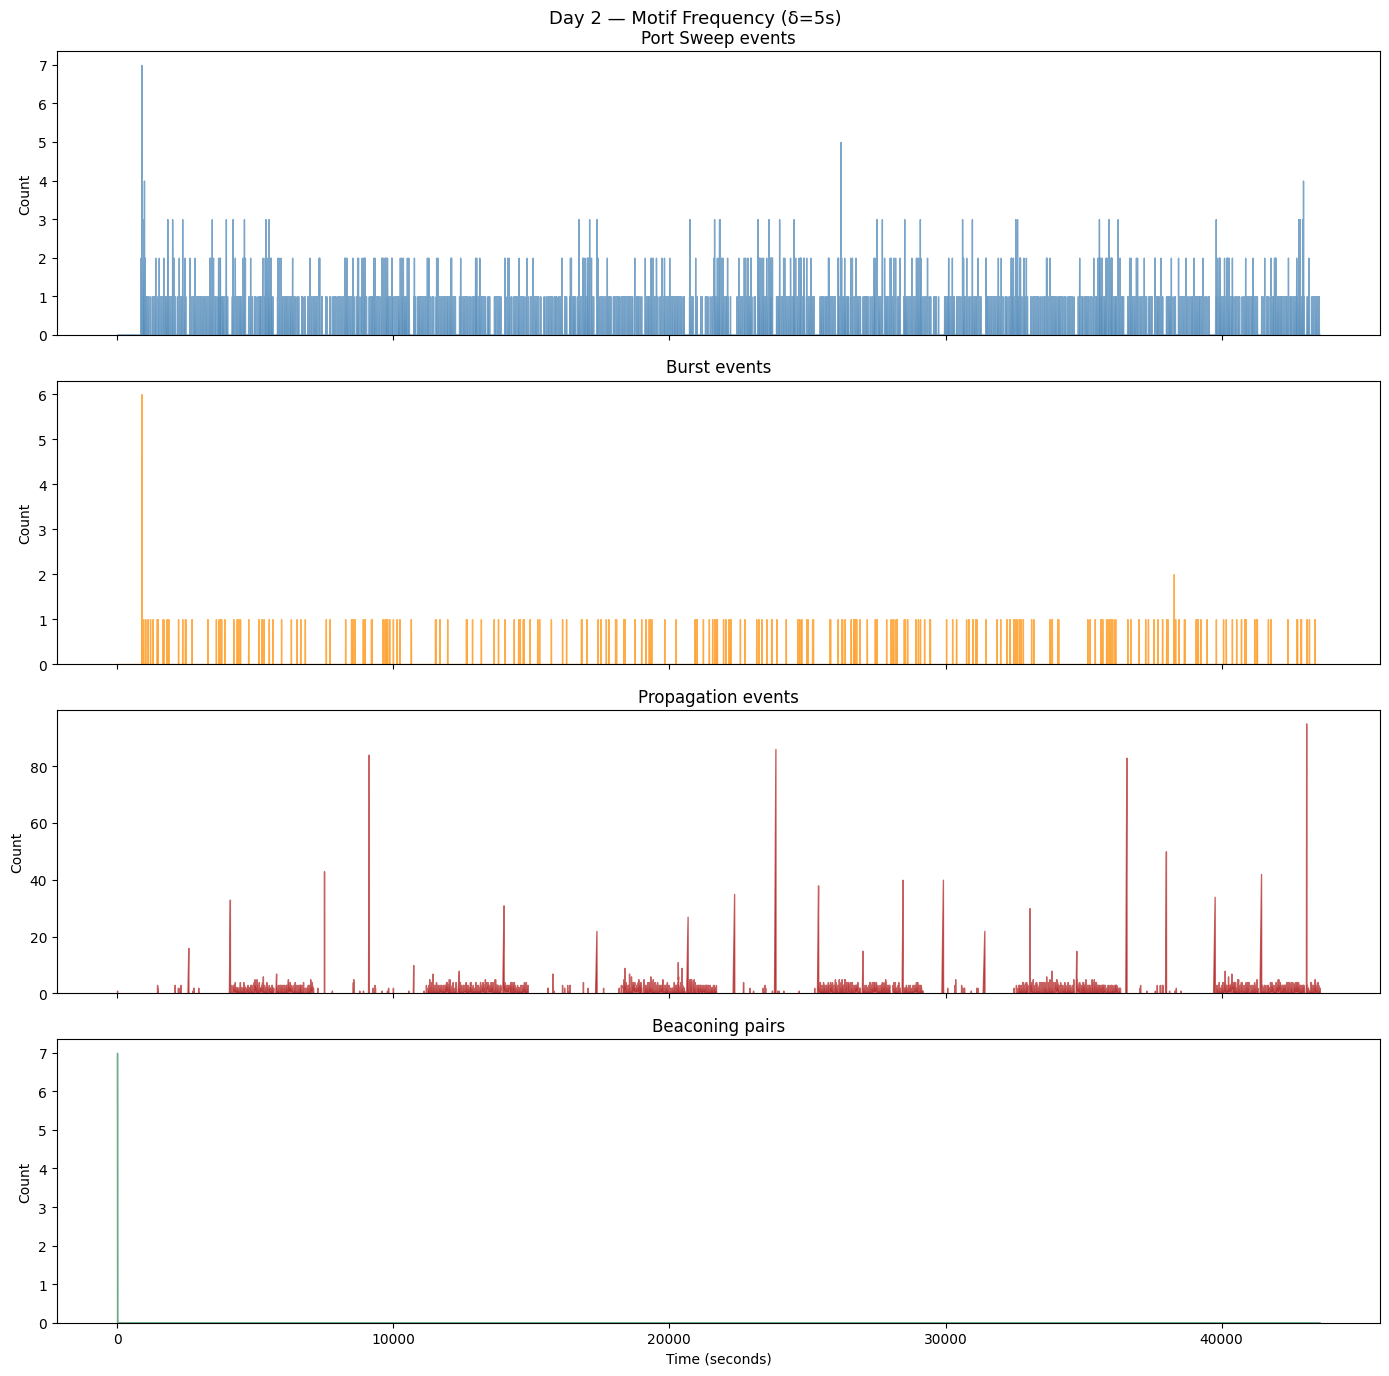

In [31]:
def detect_beaconing(df, cv_threshold=0.4, min_count=3):
    grouped = df.groupby([SRC, DST])[TIME_COL].apply(list)
    results = []
    for (src, dst), times in grouped.items():
        if len(times) < min_count:
            continue
        iats = np.diff(sorted(times))
        if len(iats) == 0 or iats.mean() == 0:
            continue
        cv = variation(iats)
        if cv < cv_threshold:
            results.append({'src': src, 'dst': dst,
                            'count': len(times), 'cv': cv})
    return pd.DataFrame(results)

def detect_port_sweep(df, ts_min, delta_ms=DELTA_MS, min_unique_dst=5):
    df = df.copy()
    df['snapshot_id'] = ((df[TIME_COL] - ts_min) // delta_ms).astype(int)
    sweeps = (
        df.groupby([SRC, 'L4_DST_PORT', 'snapshot_id'])
        .agg(unique_dst=(DST, 'nunique'),
             attack_ratio=(LABEL, 'mean'),
             flow_count=(DST, 'count'))
        .reset_index()
    )
    return sweeps[sweeps['unique_dst'] >= min_unique_dst]

def detect_bursts(df, ts_min, delta_ms=DELTA_MS, burst_threshold=50):
    df = df.copy()
    df['snapshot_id'] = ((df[TIME_COL] - ts_min) // delta_ms).astype(int)
    burst_counts = (
        df.groupby([SRC, 'snapshot_id'])
        .agg(count=(TIME_COL, 'count'),
             attack_ratio=(LABEL, 'mean'))
        .reset_index()
    )
    return burst_counts[burst_counts['count'] >= burst_threshold]

def detect_propagation(snaps, dataset_pl, delta_ms=DELTA_MS, outer_pbar=None):
    a_nb = (
        dataset_pl.select([SRC, DST]).unique()
        .group_by(SRC).agg(pl.col(DST).alias('neighbours'))
    )
    nb_dict = {r[SRC]: set(r['neighbours']) for r in a_nb.to_dicts()}
    results = []
    total   = len(snaps)
    for i, (sid, G_t) in enumerate(snaps.items()):
        if outer_pbar is not None:
            outer_pbar.set_postfix(
                {'snapshot': f'{i+1}/{total}'}, refresh=True)
        edges      = list(G_t.edges())
        edges_from = defaultdict(list)
        for A, B in edges:
            edges_from[A].append(B)
        for A, B in edges:
            for C in edges_from.get(B, []):
                if C != A and C not in nb_dict.get(A, set()):
                    results.append({'A': A, 'B': B, 'C': C,
                                    'snapshot': sid,
                                    'time_s': sid * delta_ms / 1000})
    df_out = pd.DataFrame(results)
    if len(df_out):
        df_out = df_out.drop_duplicates(
            subset=['A', 'B', 'C', 'snapshot'])
    return df_out

def run_motifs(name, d):
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")

    df_pd = (
        d['df']
        .select([SRC, DST, TIME_COL, LABEL, 'snapshot_id',
                 'L4_DST_PORT', 'L4_SRC_PORT'])
        .to_pandas()
        .sort_values(TIME_COL)
        .reset_index(drop=True)
    )
    ts_min   = d['ts_min']
    snap_ids = sorted(d['snaps'].keys())

    steps = ['Beaconing', 'Port Sweep', 'Bursts', 'Propagation']
    pbar  = tqdm(steps, position=0, leave=True)

    pbar.set_description('Beaconing')
    beacons = detect_beaconing(df_pd)
    print(f"\n  Beaconing pairs : {len(beacons):,}")
    pbar.update(1)

    pbar.set_description('Port Sweep')
    sweeps = detect_port_sweep(df_pd, ts_min)
    print(f"  Port sweeps     : {len(sweeps):,}  "
          f"avg attack ratio: {sweeps['attack_ratio'].mean()*100:.1f}%")
    pbar.update(1)

    pbar.set_description('Bursts')
    bursts = detect_bursts(df_pd, ts_min)
    print(f"  Bursts          : {len(bursts):,}  "
          f"avg attack ratio: {bursts['attack_ratio'].mean()*100:.1f}%")
    pbar.update(1)

    pbar.set_description('Propagation')
    propagations = detect_propagation(d['snaps'], d['raw'], outer_pbar=pbar)
    print(f"  Propagations    : {len(propagations):,}")
    pbar.update(1)
    pbar.set_description('Done')
    pbar.close()

    # ── Plot ──────────────────────────────────────────────────────────────────
    sweep_snap = sweeps.groupby('snapshot_id').size().to_dict()
    burst_snap = bursts.groupby('snapshot_id').size().to_dict()
    prop_snap  = (propagations['snapshot'].value_counts().to_dict()
                  if len(propagations) else {})
    t_axis = np.array(snap_ids) * DELTA_MS / 1000

    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
    fig.suptitle(f'{name} — Motif Frequency (δ={DELTA_MS//1000}s)',
                 fontsize=13)
    for ax, (title, snap_dict, colour) in zip(axes, [
        ('Port Sweep events',  sweep_snap, 'steelblue'),
        ('Burst events',       burst_snap, 'darkorange'),
        ('Propagation events', prop_snap,  'firebrick'),
        ('Beaconing pairs',
         {snap_ids[0]: len(beacons)} if len(beacons) else {},
         'seagreen'),
    ]):
        y = [snap_dict.get(s, 0) for s in snap_ids]
        ax.fill_between(t_axis, y, alpha=0.7, color=colour)
        ax.set_ylabel('Count')
        ax.set_title(title)
        ax.set_ylim(bottom=0)
    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.show()

    return dict(beacons=beacons, sweeps=sweeps,
                bursts=bursts, propagations=propagations)

motif_results = {}
for name, d in days.items():
    motif_results[name] = run_motifs(name, d)

Day 1 evolution: 100%|██████████| 8633/8633 [00:38<00:00, 224.17it/s]


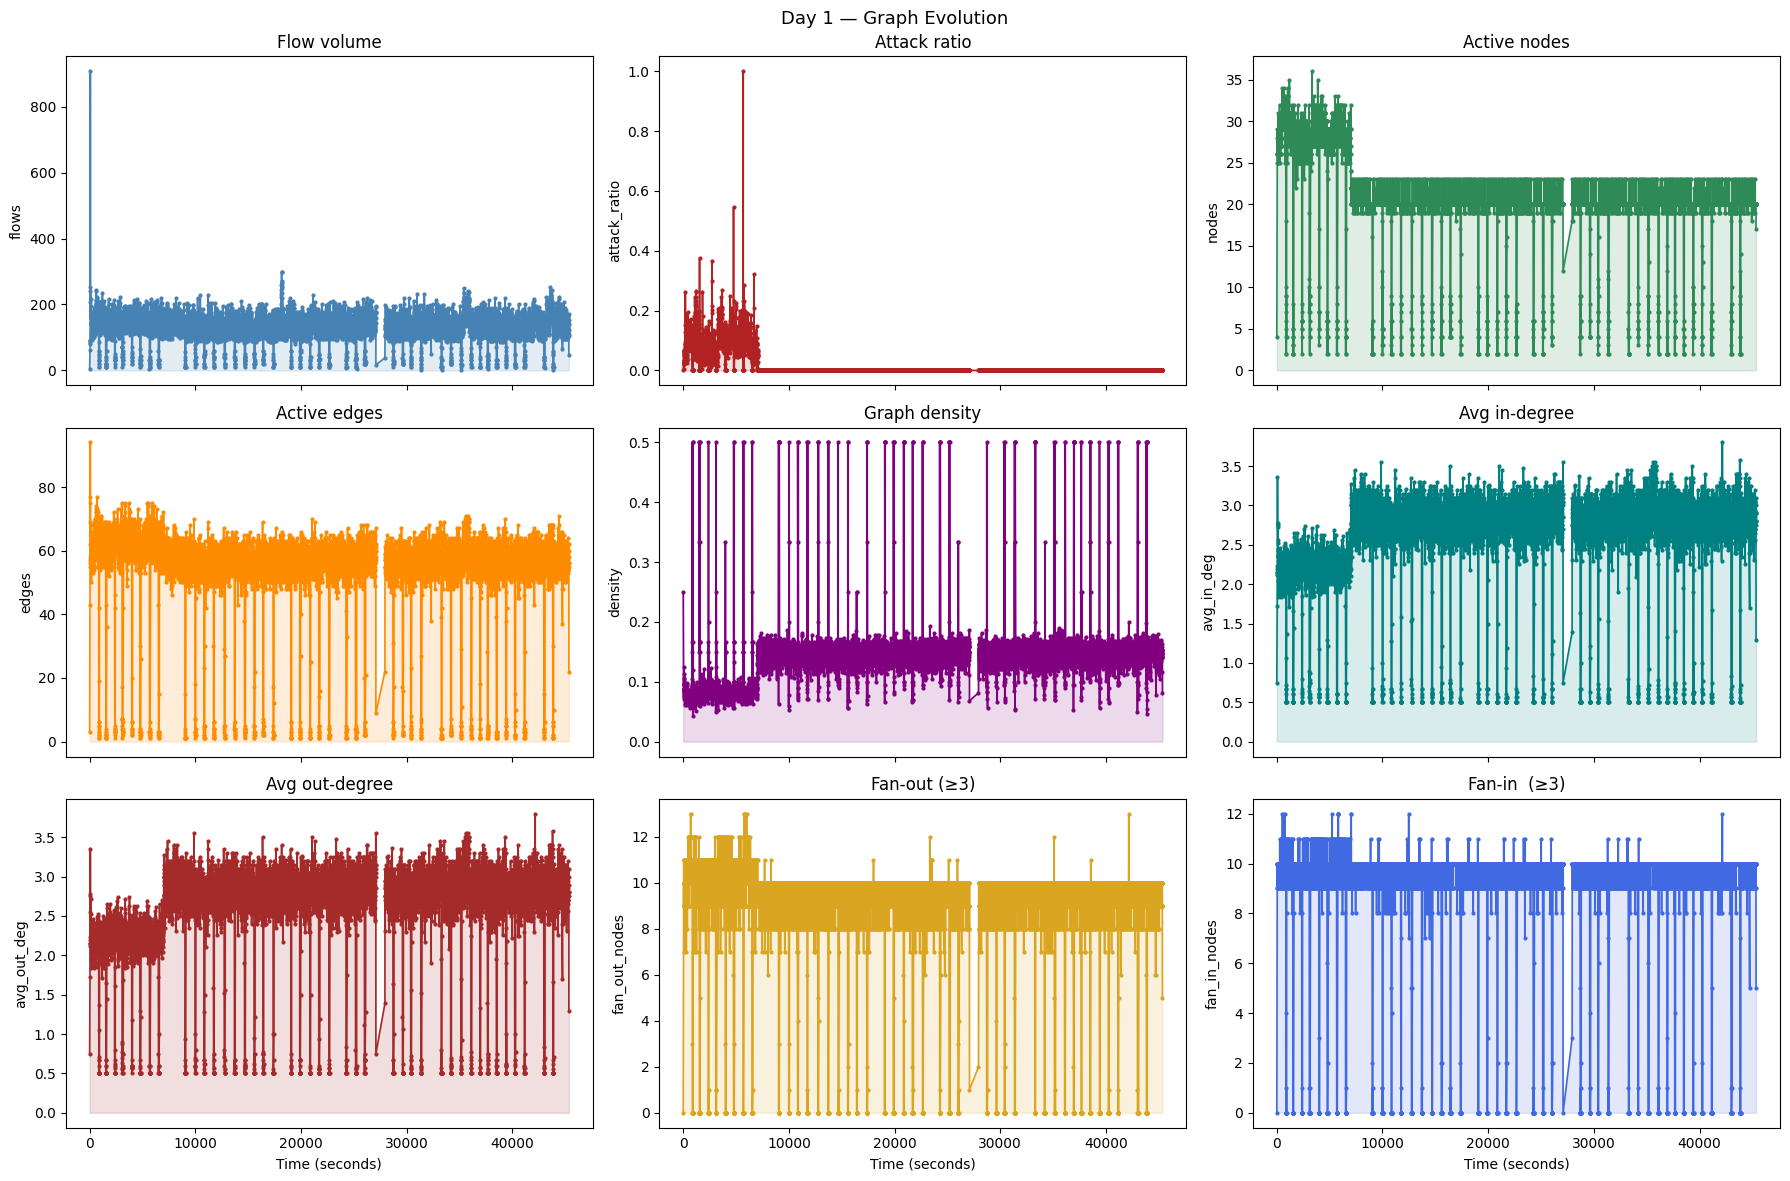


Day 1 — Evolution summary:
shape: (9, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ snapshot_ ┆ time_s    ┆ flows     ┆ … ┆ avg_in_de ┆ avg_out_d ┆ fan_out_n ┆ fan_in_n │
│ ---       ┆ id        ┆ ---       ┆ ---       ┆   ┆ g         ┆ eg        ┆ odes      ┆ odes     │
│ str       ┆ ---       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ f64       ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 8633.0    ┆ 8633.0    ┆ 8633.0    ┆ … ┆ 8633.0    ┆ 8633.0    ┆ 8633.0    ┆ 8633.0   │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 4516.6146 ┆ 22583.073 ┆ 131.51303 

Day 2 evolution: 100%|██████████| 8412/8412 [00:28<00:00, 294.96it/s]


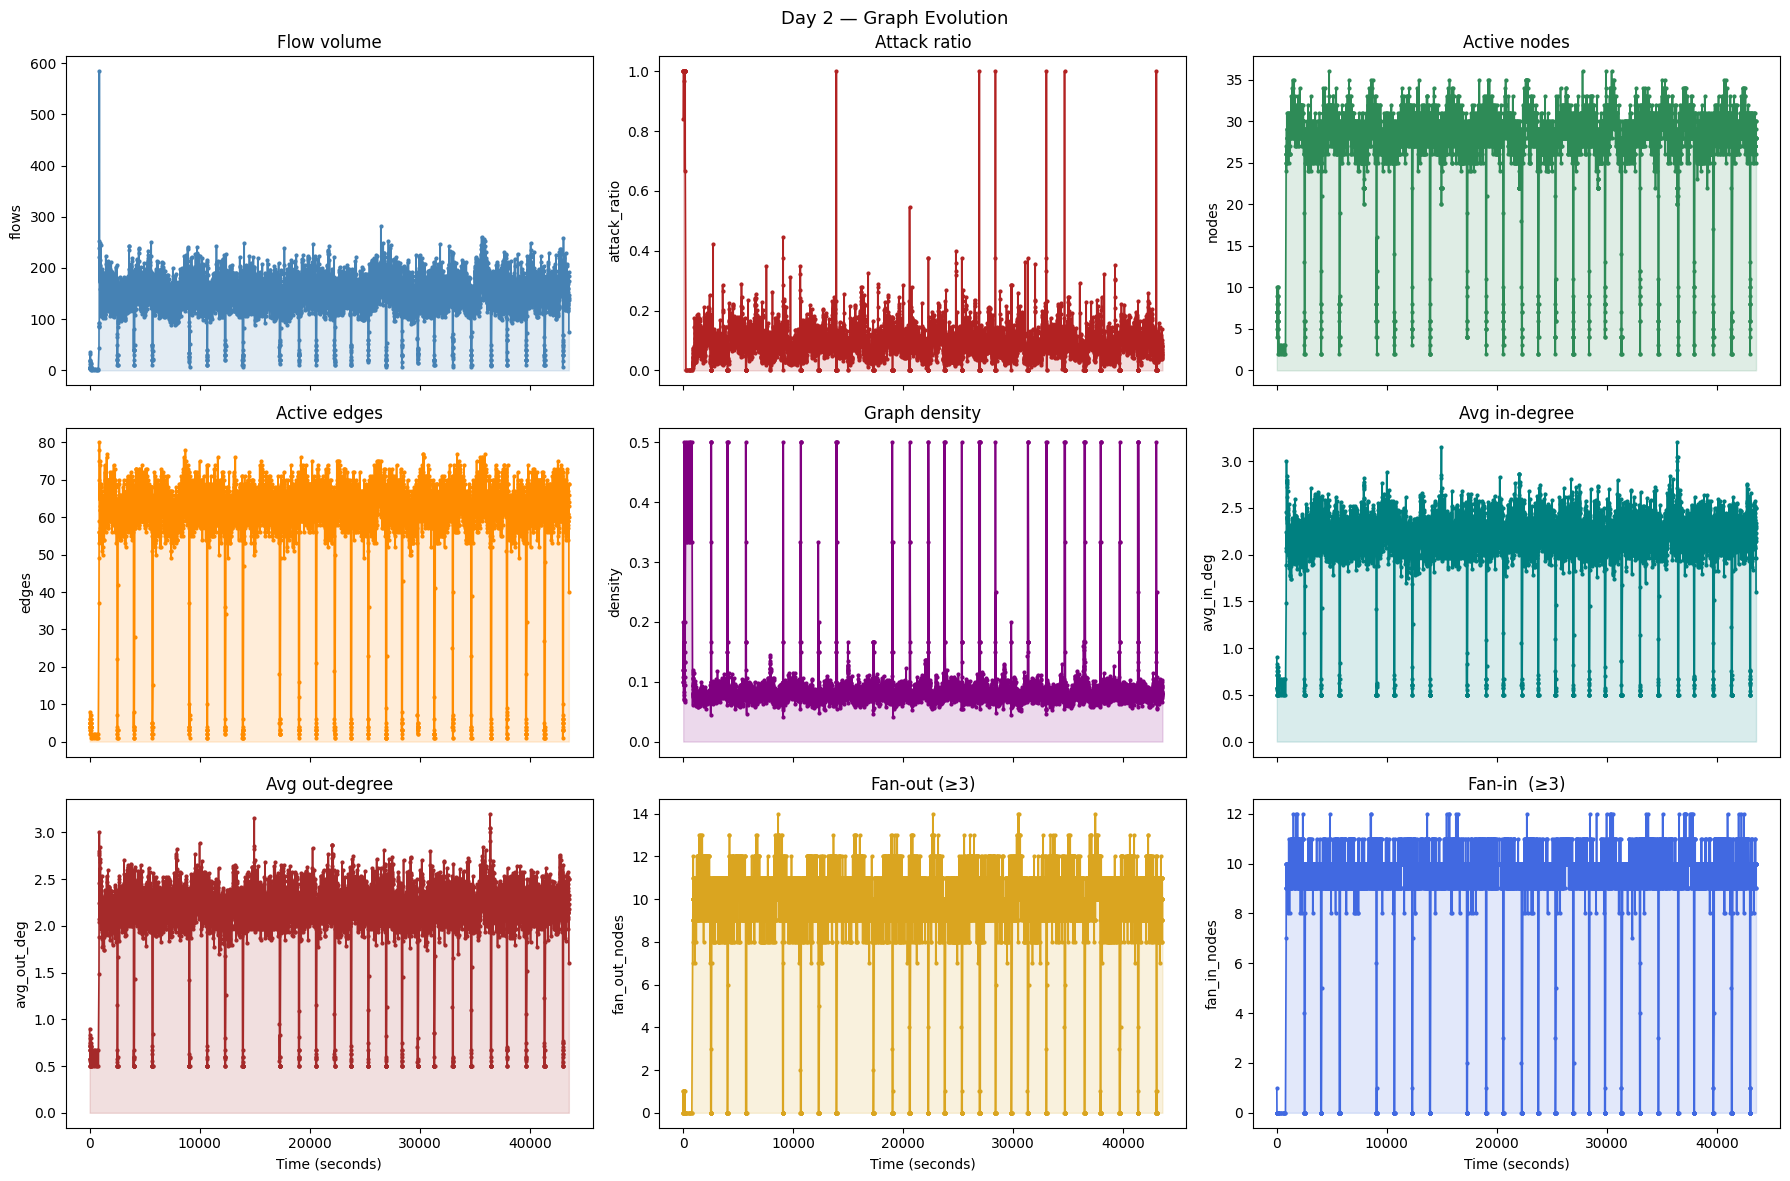


Day 2 — Evolution summary:
shape: (9, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ snapshot_ ┆ time_s    ┆ flows     ┆ … ┆ avg_in_de ┆ avg_out_d ┆ fan_out_n ┆ fan_in_n │
│ ---       ┆ id        ┆ ---       ┆ ---       ┆   ┆ g         ┆ eg        ┆ odes      ┆ odes     │
│ str       ┆ ---       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ f64       ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 8412.0    ┆ 8412.0    ┆ 8412.0    ┆ … ┆ 8412.0    ┆ 8412.0    ┆ 8412.0    ┆ 8412.0   │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 4410.6370 ┆ 22053.185 ┆ 146.22824 

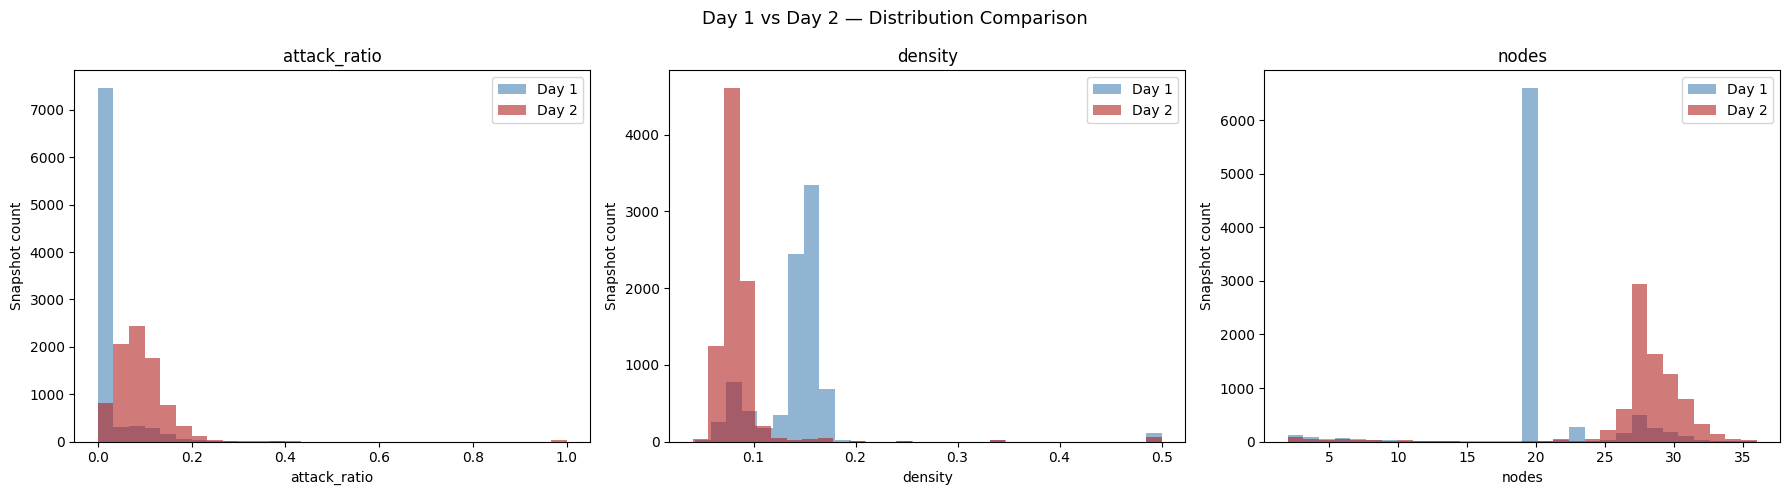

In [32]:
def analyse_evolution(name, d):
    snaps    = d['snaps']
    df       = d['df']
    snap_ids = sorted(snaps.keys())
    THRESH   = 3

    records = []
    for sid in tqdm(snap_ids, desc=f'{name} evolution', leave=True):
        G_t     = snaps[sid]
        G_t_und = G_t.to_undirected()
        sdf     = df.filter(pl.col('snapshot_id') == sid)
        n       = G_t_und.number_of_nodes()
        out_deg = dict(G_t.out_degree())
        in_deg  = dict(G_t.in_degree())
        records.append({
            'snapshot_id'   : sid,
            'time_s'        : sid * DELTA_MS / 1000,
            'flows'         : len(sdf),
            'attack_ratio'  : sdf[LABEL].mean(),
            'nodes'         : n,
            'edges'         : G_t_und.number_of_edges(),
            'density'       : nx.density(G_t),
            'avg_in_deg'    : np.mean(list(in_deg.values()))  if n else 0,
            'avg_out_deg'   : np.mean(list(out_deg.values())) if n else 0,
            'fan_out_nodes' : sum(1 for v in out_deg.values() if v >= THRESH),
            'fan_in_nodes'  : sum(1 for v in in_deg.values()  if v >= THRESH),
        })

    met = pl.DataFrame(records)
    t   = met['time_s'].to_numpy()

    fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
    fig.suptitle(f'{name} — Graph Evolution', fontsize=13)
    plot_cols = [
        ('flows',         'Flow volume',        'steelblue'),
        ('attack_ratio',  'Attack ratio',       'firebrick'),
        ('nodes',         'Active nodes',       'seagreen'),
        ('edges',         'Active edges',       'darkorange'),
        ('density',       'Graph density',      'purple'),
        ('avg_in_deg',    'Avg in-degree',      'teal'),
        ('avg_out_deg',   'Avg out-degree',     'brown'),
        ('fan_out_nodes', f'Fan-out (≥{THRESH})','goldenrod'),
        ('fan_in_nodes',  f'Fan-in  (≥{THRESH})','royalblue'),
    ]
    for ax, (col, title, colour) in zip(axes.flat, plot_cols):
        y = met[col].to_numpy()
        ax.plot(t, y, color=colour, linewidth=1.2,
                marker='o', markersize=2)
        ax.fill_between(t, y, alpha=0.15, color=colour)
        ax.set_title(title)
        ax.set_ylabel(col)
    for ax in axes[-1]:
        ax.set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.show()

    print(f"\n{name} — Evolution summary:")
    print(met.describe())
    return met

evolution_results = {}
for name, d in days.items():
    evolution_results[name] = analyse_evolution(name, d)

# ── Cross-day comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Day 1 vs Day 2 — Distribution Comparison', fontsize=13)
metrics = ['attack_ratio', 'density', 'nodes']
for ax, col in zip(axes, metrics):
    for name, colour in zip(days.keys(), ['steelblue', 'firebrick']):
        ax.hist(evolution_results[name][col].to_numpy(),
                bins=30, alpha=0.6, label=name, color=colour)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Snapshot count')
    ax.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_6877/565994388.py:24: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col(SRC).replace(partition_map, default=-1).alias('partition')


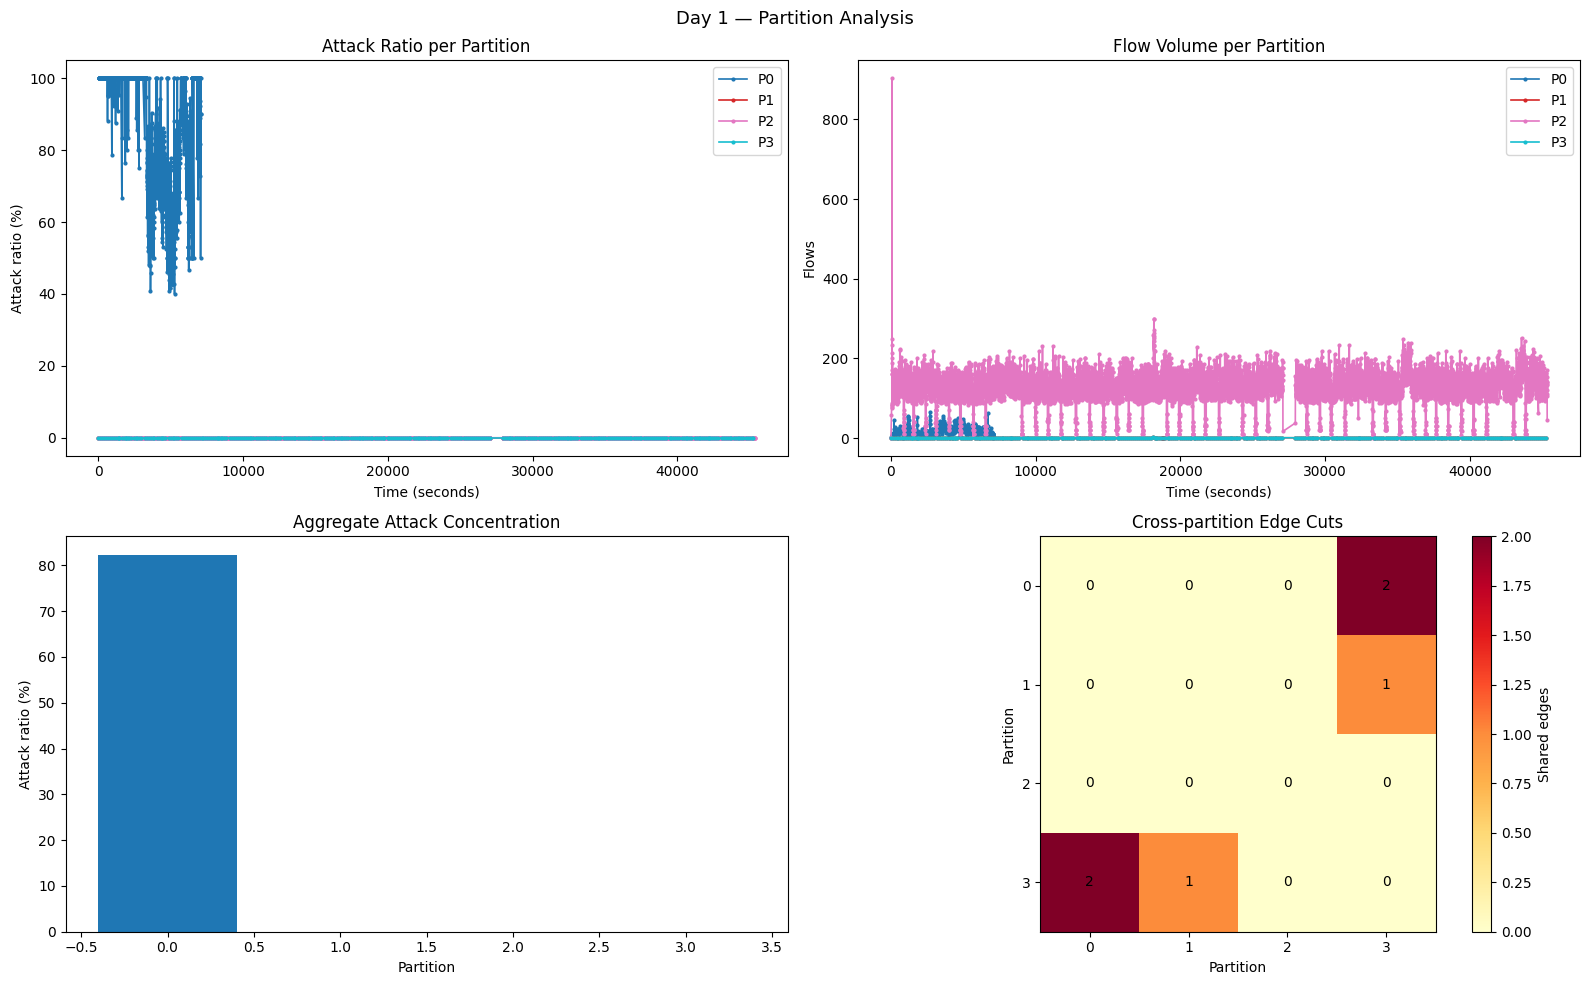


Day 1 — Partition summary:
  Edge cut: 3 / 148 (2.0%)
shape: (4, 3)
┌───────────┬─────────┬──────────────┐
│ partition ┆ flows   ┆ attack_ratio │
│ ---       ┆ ---     ┆ ---          │
│ i64       ┆ u32     ┆ f64          │
╞═══════════╪═════════╪══════════════╡
│ 0         ┆ 21233   ┆ 0.822399     │
│ 1         ┆ 324     ┆ 0.0          │
│ 2         ┆ 1113472 ┆ 0.0          │
│ 3         ┆ 323     ┆ 0.0          │
└───────────┴─────────┴──────────────┘


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_6877/565994388.py:24: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col(SRC).replace(partition_map, default=-1).alias('partition')


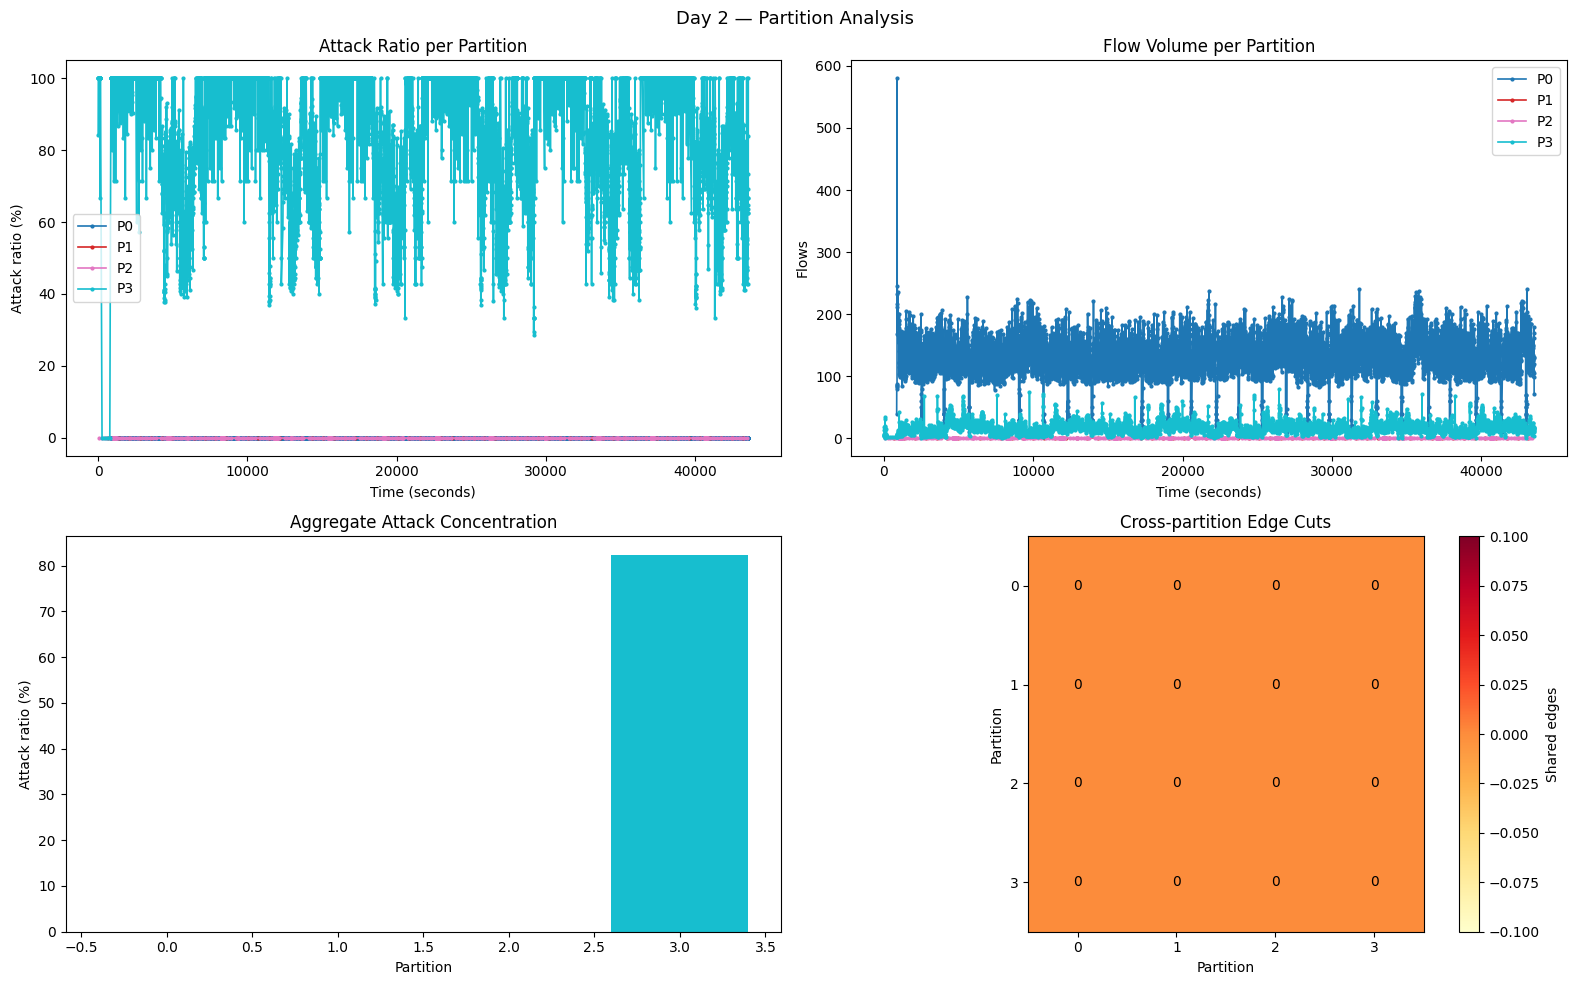


Day 2 — Partition summary:
  Edge cut: 0 / 153 (0.0%)
shape: (4, 3)
┌───────────┬─────────┬──────────────┐
│ partition ┆ flows   ┆ attack_ratio │
│ ---       ┆ ---     ┆ ---          │
│ i64       ┆ u32     ┆ f64          │
╞═══════════╪═════════╪══════════════╡
│ 0         ┆ 1095616 ┆ 0.0          │
│ 1         ┆ 58      ┆ 0.0          │
│ 2         ┆ 479     ┆ 0.0          │
│ 3         ┆ 133919  ┆ 0.823117     │
└───────────┴─────────┴──────────────┘


In [33]:
def analyse_partitioning(name, d, N_PARTS=4):
    G_und    = d['G_und']
    df       = d['df']
    snaps    = d['snaps']
    snap_ids = sorted(snaps.keys())
    nodes    = list(G_und.nodes())
    node_idx = {n: i for i, n in enumerate(nodes)}

    # ── Spectral partition ────────────────────────────────────────────────────
    adj = nx.to_scipy_sparse_array(G_und, nodelist=nodes, format='csr')
    adj = adj.astype(np.float64)
    adj.indices = adj.indices.astype(np.int32)
    adj.indptr  = adj.indptr.astype(np.int32)

    sc = SpectralClustering(
        n_clusters=N_PARTS, affinity='precomputed',
        assign_labels='kmeans', random_state=42, n_init=10
    )
    node_partition = sc.fit_predict(adj)
    partition_map  = {n: int(p) for n, p in zip(nodes, node_partition)}

    # ── Assign partition to flows via SRC ─────────────────────────────────────
    df_part = df.with_columns(
        pl.col(SRC).replace(partition_map, default=-1).alias('partition')
    )

    # ── Per-partition per-snapshot stats ──────────────────────────────────────
    part_time = (
        df_part.group_by(['snapshot_id', 'partition'])
        .agg([pl.len().alias('flows'),
              pl.col(LABEL).mean().alias('attack_ratio')])
        .sort(['partition', 'snapshot_id'])
    )

    colours = cm.tab10(np.linspace(0, 1, N_PARTS))
    t_axis  = np.array(snap_ids) * DELTA_MS / 1000

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{name} — Partition Analysis', fontsize=13)

    # Attack ratio over time per partition
    for p in range(N_PARTS):
        pdf  = part_time.filter(pl.col('partition') == p).sort('snapshot_id')
        t_p  = pdf['snapshot_id'].to_numpy() * DELTA_MS / 1000
        axes[0, 0].plot(t_p, pdf['attack_ratio'].to_numpy() * 100,
                        label=f'P{p}', color=colours[p],
                        linewidth=1.2, marker='o', markersize=2)
    axes[0, 0].set_title('Attack Ratio per Partition')
    axes[0, 0].set_ylabel('Attack ratio (%)')
    axes[0, 0].set_xlabel('Time (seconds)')
    axes[0, 0].legend()

    # Flow volume over time per partition
    for p in range(N_PARTS):
        pdf  = part_time.filter(pl.col('partition') == p).sort('snapshot_id')
        t_p  = pdf['snapshot_id'].to_numpy() * DELTA_MS / 1000
        axes[0, 1].plot(t_p, pdf['flows'].to_numpy(),
                        label=f'P{p}', color=colours[p],
                        linewidth=1.2, marker='o', markersize=2)
    axes[0, 1].set_title('Flow Volume per Partition')
    axes[0, 1].set_ylabel('Flows')
    axes[0, 1].set_xlabel('Time (seconds)')
    axes[0, 1].legend()

    # Aggregate attack concentration
    agg_part = (
        df_part.group_by('partition')
        .agg([pl.len().alias('flows'),
              pl.col(LABEL).mean().alias('attack_ratio')])
        .sort('partition')
        .filter(pl.col('partition') >= 0)
    )
    parts = agg_part['partition'].to_list()
    axes[1, 0].bar(parts,
                   agg_part['attack_ratio'].to_numpy() * 100,
                   color=[colours[p] for p in parts])
    axes[1, 0].set_title('Aggregate Attack Concentration')
    axes[1, 0].set_ylabel('Attack ratio (%)')
    axes[1, 0].set_xlabel('Partition')

    # Cross-partition edge cuts
    cross = np.zeros((N_PARTS, N_PARTS), dtype=int)
    for u, v in G_und.edges():
        pu = partition_map.get(u, -1)
        pv = partition_map.get(v, -1)
        if pu >= 0 and pv >= 0 and pu != pv:
            cross[pu, pv] += 1
            cross[pv, pu] += 1
    im = axes[1, 1].imshow(cross, cmap='YlOrRd')
    axes[1, 1].set_title('Cross-partition Edge Cuts')
    axes[1, 1].set_xlabel('Partition')
    axes[1, 1].set_ylabel('Partition')
    axes[1, 1].set_xticks(range(N_PARTS))
    axes[1, 1].set_yticks(range(N_PARTS))
    for i in range(N_PARTS):
        for j in range(N_PARTS):
            axes[1, 1].text(j, i, cross[i, j],
                            ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=axes[1, 1], label='Shared edges')

    plt.tight_layout()
    plt.show()

    edge_cuts = sum(1 for u, v in G_und.edges()
                    if partition_map.get(u) != partition_map.get(v))
    print(f"\n{name} — Partition summary:")
    print(f"  Edge cut: {edge_cuts:,} / {G_und.number_of_edges():,} "
          f"({edge_cuts/G_und.number_of_edges()*100:.1f}%)")
    print(agg_part)

    return dict(partition_map=partition_map, agg_part=agg_part)

partition_results = {}
for name, d in days.items():
    partition_results[name] = analyse_partitioning(name, d)